In [1]:
### We will try to fit 4 Optical Depth Spectra from the hfs OH lines:
# We will keep the FWHM and center velocity as two free parameters,
# Then we will let the amplitudes vary for 6 free parameters per Gaussian.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import ascii

from io import StringIO

from lmfit import Model, minimize, Parameters, report_fit, fit_report
from lmfit.models import GaussianModel

import astropy.table as Table
from astropy import units as u
from astropy import constants as con
import pandas as pd
import OHfunc as O

import plotly.express as px

In [3]:
# Write out function to model:

const = np.sqrt(np.pi)/(2.0*np.sqrt(np.log(2.0)))

def gauss(x, amp, cen, sigma):
    """Gaussian lineshape."""
    return amp * np.exp(-(x-cen)**2 / (2.*sigma**2))

# Have to change error to be on -baseline- region, will implement later.
def ew(x,y,rms,lower=0, upper=10):
    delta = abs(x[0]-x[1])
    print(delta)
    idx = np.where((x >= lower) & (x <= upper))
    integral = np.sum(y[idx])*delta
    error = rms*np.sqrt(len(idx[0]))*delta
    print(len(idx[0]))
    return integral, error

def rms(x,y, lower=-20, upper=0):
    idx = np.where((x >= lower) & (x <= upper))
    return np.std(y[idx])

# Calculate Excitation Temperatures per line:

def ex(ew, Noh, line=67):
    #Normalized N(OH) by:
    Noh = Noh/1e14
    # Given a measured ew and Tc, and a Noh from SOFIA 2.5Thz, calculate the excitation temp
     # The equation to invert is (Neufeld 2002):
    # W_v = 0.45 *k [N(OH)/e14]/Tex (Here we assume Tc > 1000K)
    
    if line==67:
        k = 1
    elif line==65:
        k = 5/9
    elif line==12:
        k = 1/9
    elif line==20:
        k = 1/9
    else:
        print("Specify an OH line with an integer: 67, 65, 12 or 20 for 1667, 1665, 1612, 1720 MHz")
        
    return (0.45 * k * Noh)/ew


# Calculate the column density 

def Nfit(out, i):
    '''
    Calculate the column density from the SOFIA lines.
    
    out: array of fitted parameter values
    i: component number
    '''
    
    # For 316, which is the strongest line
    EW316 = out.params[f'amp316_{i}'].value
    sigEW316 = out.params[f'amp316_{i}'].stderr
    
    f316 = 2514.3167*u.GHz
    omega316 = ((7*0.1368)/16)*np.exp(-120.75/2.73)
    N_316 = (8 * np.pi * (f316.cgs**3))/((con.c.cgs)**3 * omega316/u.s) * (np.exp(((con.h * 2514.3167*u.GHz)/(con.k_B*2.73*u.K)))-1)**-1 * np.abs(EW316)/u.s*u.cm*10**5
    N_316_err = (8 * np.pi * (f316.cgs**3))/((con.c.cgs)**3 * omega316/u.s) * (np.exp(((con.h * 2514.3167*u.GHz)/(con.k_B*2.73*u.K)))-1)**-1 * np.abs(sigEW316)/u.s*u.cm*10**5
    
    # For 298, which is the strongest line
    EW298 = out.params[f'amp298_{i}'].value
    sigEW298 = out.params[f'amp298_{i}'].stderr
    
    f298 = 2514.2987*u.GHz
    omega298 = ((5*0.0137)/16)*np.exp(-120.75/2.73)
    N_298 = (8 * np.pi * (f298.cgs**3))/((con.c.cgs)**3 * omega298/u.s) * (np.exp(((con.h * 2514.2987*u.GHz)/(con.k_B*2.73*u.K)))-1)**-1 * np.abs(EW298)/u.s*u.cm*10**5
    N_298_err = (8 * np.pi * (f298.cgs**3))/((con.c.cgs)**3 * omega298/u.s) * (np.exp(((con.h * 2514.2987*u.GHz)/(con.k_B*2.73*u.K)))-1)**-1 * np.abs(sigEW298)/u.s*u.cm*10**5
    
    # For 353, which is the strongest line
    EW353 = out.params[f'amp353_{i}'].value
    sigEW353 = out.params[f'amp353_{i}'].stderr
    
    f353 = 2514.3532*u.GHz
    omega353 = ((5*0.1231)/16)*np.exp(-120.75/2.73)
    N_353 = (8 * np.pi * (f353.cgs**3))/((con.c.cgs)**3 * omega353/u.s) * (np.exp(((con.h * 2514.3532*u.GHz)/(con.k_B*2.73*u.K)))-1)**-1 * np.abs(EW353)/u.s*u.cm*10**5
    N_353_err = (8 * np.pi * (f353.cgs**3))/((con.c.cgs)**3 * omega353/u.s) * (np.exp(((con.h * 2514.3532*u.GHz)/(con.k_B*2.73*u.K)))-1)**-1 * np.abs(sigEW353)/u.s*u.cm*10**5
    
    return N_316 + N_298 + N_353, np.sqrt(N_316_err**2 + N_298_err**2 + N_353_err**2)

# Calculate the energy differences between states:
E31 = (1665.4018*u.MHz * con.h)/con.k_B # 1665 MHz
E_1665 = E31.to('Kelvin')

E42 = (1667.359*u.MHz * con.h)/con.k_B # 1667 MHz
E_1667 = E42.to('Kelvin')

E41 = (1720.5299*u.MHz * con.h)/con.k_B # 1720 MHz
E_1720 = E41.to('Kelvin')

E32 = (1612.2309*u.MHz * con.h)/con.k_B # 1612 MHz
E_1612 = E32.to('Kelvin')

In [4]:
f316 = 2514.3167*u.GHz
omega316 = ((7*0.1368)/16)*np.exp(-120.75/2.73)

f298 = 2514.2987*u.GHz
omega298 = ((5*0.0137)/16)*np.exp(-120.75/2.73)

f353 = 2514.3532*u.GHz
omega353 = ((5*0.1231)/16)*np.exp(-120.75/2.73)

In [5]:
N_316 = (8 * np.pi * (f316.cgs**3))/((con.c.cgs)**3 * omega316/u.s) * (np.exp(((con.h * 2514.3167*u.GHz)/(con.k_B*2.73*u.K)))-1)**-1 * 0.99/u.s*u.cm*10**5
N_298 = (8 * np.pi * (f298.cgs**3))/((con.c.cgs)**3 * omega298/u.s) * (np.exp(((con.h * 2514.2987*u.GHz)/(con.k_B*2.73*u.K)))-1)**-1 * 0.07/u.s*u.cm*10**5
N_353 = (8 * np.pi * (f353.cgs**3))/((con.c.cgs)**3 * omega353/u.s) * (np.exp(((con.h * 2514.3532*u.GHz)/(con.k_B*2.73*u.K)))-1)**-1 * 0.63/u.s*u.cm*10**5

In [6]:
print(N_316)
print(N_298)
print(N_353)
N_316 + N_298 + N_353

25271232224432.25 1 / cm2
24986816529991.414 1 / cm2
25005071409459.953 1 / cm2


<Quantity 7.52631202e+13 1 / cm2>

In [7]:
# Code to perform Gaussian Fitting:
# Note to self: I have cleaned this up a bit but each function should generally have a docstring.
# To Do: 
# Write doc strings for each function, clarify inputs and outputs.

# Change to this notebook, we fit equivalent width rather than 'amplitude' to properly determine
# errors in this parameter which is needed for David's fitting.

# To Do list:
# * write more doc strings.
# * put on github
# * fit rest of sources.
# * send David results of 'trusted' results.
# * incorporate N(OH) errors.

In [8]:
def gauss_dataset_VLA(params, n, i, x):
    """Calculate Gaussian lineshape from parameters for chosen data set."""
    if i == 0:
        amp = params[f'amp1667_{i+1}_{n}']
        cen = params[f'cen1667_{i+1}_{n}']
        sig = params[f'sig1667_{i+1}_{n}']
    
    # For i == 1, we label this the 1665 MHz line and call those parameters.
    elif i == 1:
        amp = params[f'amp1665_{i+1}_{n}']
        cen = params[f'cen1665_{i+1}_{n}']
        sig = params[f'sig1665_{i+1}_{n}']
    
    # For i == 2, we label this the 1612 MHz line and call those parameters.
    elif i == 2:
        amp = params[f'amp1612_{i+1}_{n}']
        cen = params[f'cen1612_{i+1}_{n}']
        sig = params[f'sig1612_{i+1}_{n}']
            
    # For i == 3, we label this the 1720 MHz line and call those parameters.
    elif i == 3:
        amp = params[f'amp1720_{i+1}_{n}']
        cen = params[f'cen1720_{i+1}_{n}']
        sig = params[f'sig1720_{i+1}_{n}']
     
    return gauss(x, amp=amp/(sig*2.355*1.0645), cen=cen, sigma=sig)

def gauss_dataset_sof(params, n, line, x):
    """Calculate Gaussian lineshape from parameters for chosen data set."""
    if line == "316":
        amp = params[f'amp316_{n}']
        cen = params[f'cen316_{n}']
        sig = params[f'sig316_{n}']
    
    # For i == 1, we label this the 1665 MHz line and call those parameters.
    elif line == "298":
        amp = params[f'amp298_{n}']
        cen = params[f'cen298_{n}']
        sig = params[f'sig298_{n}']
    
    # For i == 2, we label this the 1612 MHz line and call those parameters.
    elif line == "353":
        amp = params[f'amp353_{n}']
        cen = params[f'cen353_{n}']
        sig = params[f'sig353_{n}']
    
    # Fit to tau:
    gsave = np.exp(gauss(x, amp=amp/(sig*2.355*1.0645), cen=cen, sigma=sig)) - 1

    return gsave

def gauss_dataset_n(params, n, i, x):
    """Calculate Gaussian lineshape from parameters for data set."""
    # Model array:
    model = []
    
    # For i == 0, we label this the 1667 MHz line and call those parameters.
    if i == 0:
        for q in range(n):
            amp = params[f'amp1667_{i+1}_{q}']
            cent = params[f'cen1667_{i+1}_{q}']
            sig = params[f'sig1667_{i+1}_{q}']
            model.append(gauss(x=x, amp=amp/(sig*2.355*1.0645), cen=cent, sigma=sig))
    
    # For i == 1, we label this the 1665 MHz line and call those parameters.
    elif i == 1:
        for q in range(n):
            amp = params[f'amp1665_{i+1}_{q}']
            cent = params[f'cen1665_{i+1}_{q}']
            sig = params[f'sig1665_{i+1}_{q}']
            model.append(gauss(x=x, amp=amp/(sig*2.355*1.0645), cen=cent, sigma=sig))
    
    # For i == 2, we label this the 1612 MHz line and call those parameters.
    elif i == 2:
        for q in range(n):
            amp = params[f'amp1612_{i+1}_{q}']
            cent = params[f'cen1612_{i+1}_{q}']
            sig = params[f'sig1612_{i+1}_{q}']
            model.append(gauss(x=x, amp=amp/(sig*2.355*1.0645), cen=cent, sigma=sig))
            
    # For i == 3, we label this the 1720 MHz line and call those parameters.
    elif i == 3:
        for q in range(n):
            amp = params[f'amp1720_{i+1}_{q}']
            cent = params[f'cen1720_{i+1}_{q}']
            sig = params[f'sig1720_{i+1}_{q}']
            model.append(gauss(x=x, amp=amp/(sig*2.355*1.0645), cen=cent, sigma=sig))
    
    gsave = 0.0*model[0]
    
    for mode in model:
        gsave += mode
     
    return gsave

# Fit exp(-gauss) (look in notes)

def gauss_dataset_sof_n(params, n, x):
    """Calculate Gaussian lineshape from parameters for data set."""
    # Keys to Sofia Guassians:
    keys = [5,6,7]
    # Model array:
    model = []

    for num in keys:
        for q in range(n):
            if num == 5:
                amp = params[f'amp316_{q}']
                cent = params[f'cen316_{q}']
                sig = params[f'sig316_{q}']
                model.append(gauss(x=x, amp=amp/(sig*2.355*1.0645), cen=cent, sigma=sig))
            if num == 6:
                amp = params[f'amp298_{q}']
                cent = params[f'cen298_{q}']
                sig = params[f'sig298_{q}']
                model.append(gauss(x=x, amp=amp/(sig*2.355*1.0645), cen=cent, sigma=sig))
            if num == 7:
                amp = params[f'amp353_{q}']
                cent = params[f'cen353_{q}']
                sig = params[f'sig353_{q}']
                model.append(gauss(x=x, amp=amp/(sig*2.355*1.0645), cen=cent, sigma=sig))
    
    gsave = 0.0*model[0]
    
    for mode in model:
        gsave += mode
    
    # Here we are fitting Tau:
    gsave = np.exp(gsave) - 1
    
    return gsave

def objective_sof_n(params, n, velSof, dataSof):
    """Calculate total residual for fits of Gaussians to several data sets.
    This taks 2 data arrays because the dataSof is a different velocity resolution.
    
    n = number of components
    params = parameters of each gaussian (7 gaussians per component)
    velSof = velocity axis
    dataSof = y axis"""
    
    residSof = 0.0*dataSof[:]
    
    # make residual for sofia data set:
    residSof[0,:] = dataSof[0,:] - gauss_dataset_sof_n(params, n, velSof)
    residSof = np.array(residSof)
    
    # now flatten this to a 1D array, as minimize() needs
    return residSof.flatten()

def objective_n(params, n, velVLA, velSof, dataVLA, dataSof, sigmaRadio, sigmaSof):
    """Calculate total residual for fits of Gaussians to several data sets.
    This takes 2 data arrays because the dataSof is a different velocity resolution.
    
    n = number of components
    params = parameters of each gaussian (7 gaussians per component)
    x = velocity axes
    sigmaRadio = 1 sigma channel error of the VLA data.
    sigmaSof = 1 sigma channel error of the SOFIA data."""
    ndata, _ = dataVLA.shape
    residVLA = 0.0*dataVLA[:]
    residSof = 0.0*dataSof[:]

    # make residual per VLA data set:
    for i in (0,1,2,3):
        residVLA[i, :] = (dataVLA[i, :] - gauss_dataset_n(params, n, i, velVLA))/sigmaRadio
        
    # make residual for sofia data set:
    residSof[0,:] = (dataSof[0,:] - gauss_dataset_sof_n(params, n, velSof))/sigmaSof
    
    # Data hacking to get all the data together:
    residVLA = residVLA.flatten()
    residVLA = residVLA.tolist()
    residSof = residSof[0]
    residSof = residSof.tolist()

    # Combine the data together:
    resid = residVLA + residSof
    resid = np.array(resid)
    resid = resid.flatten()

    # now flatten this to a 1D array, as minimize() needs
    return resid

# Add in the Gaussian for 18cm OH data:
def makeVLA(n, dataVLA, fit_params, c0=[0], a1667=[0], a1665=[0], a1612=[0], a1720=[0], s0=[0], lim=3):
    '''
    Purpose: Make the Gaussian models to fit to 4 hyperfine lamda doubling 18 cm OH lines.
    Guesses for the initial value of the free parameters can be provided: center velocity,
    amplitudes for 1667, 1665, 1612 and 1720, and velocity dispersion.
    
    Input:
    n = number of components in a spectrum to be fitted. e.g. if there are two components along the line of sight, n=2,
    this will make nx4 guassians  (one for each line).
    dataVLA = an np.array of each VLA spectrum, in units of optical depth ((Tmb-Tc)/Tc).
    fit_params = the initialized parameters from LMFIT (e.g. fit_params = Parameters()).
    c0 = A list containing the values for the initial guesses of the center of velocity for each Gaussian.
    a1667 = A list containing the values for the initial gueses of the amplitude of the 1667 line for each Gaussian.
    a1665 = A list containing the values for the initial gueses of the amplitude of the 1665 line for each Gaussian.
    a1612 = A list containing the values for the initial gueses of the amplitude of the 1612 line for each Gaussian.
    a1720 = A list containing the values for the initial gueses of the amplitude of the 1720 line for each Gaussian.
    s0 = A list contianing the values for the initial gueses of the velocity dispersion for each gaussian.
    
    Notes on bounds:
    The bounds on the parameters can be altered here with the min and max keywords, which use a +/- intial guess notation.
    For now the bounds are set to +/- 0.01 amplitude, +5 km/s of sigma, and +/- 1 km/s on centroid velocity.
    These bounds are quite tight and so the goodness of the fit depends on visual determination of intial conditions.
    
    Output:
    None, but Parameters will be updated.
    '''
    for q in range(n):
        for iy, y in enumerate(dataVLA):
            # Gaussian 1667
            if iy == 0:
                fit_params.add(f'amp1667_{iy+1}_{q}', value=a1667[q], min=-10, max=0)
                fit_params.add(f'cen1667_{iy+1}_{q}', value=c0[q], min = c0[q]-lim, max = c0[q]+lim)
                fit_params.add(f'sig1667_{iy+1}_{q}', value=s0[q], min=0, max=s0[q]+4)
            elif iy == 1:
                # Gaussian 1665
                fit_params.add(f'amp1665_{iy+1}_{q}', value=a1665[q], min=-10, max=0)
                fit_params.add(f'cen1665_{iy+1}_{q}', value=c0[q], min = c0[q]-lim, max = c0[q]+lim)
                fit_params.add(f'sig1665_{iy+1}_{q}', value=s0[q], min=0, max=s0[q]+4)
                # Set the 1665 to have the same parameters as 1667:
                fit_params[f'sig1665_{iy+1}_{q}'].expr = f'sig1667_1_{q}'
                fit_params[f'cen1665_{iy+1}_{q}'].expr = f'cen1667_1_{q}'
            elif iy == 2:
                # Gaussian 1612
                fit_params.add(f'amp1612_{iy+1}_{q}', value=a1612[q], min=-10, max=10)
                fit_params.add(f'cen1612_{iy+1}_{q}', value=c0[q], min = c0[q]-lim, max = c0[q]+lim)
                fit_params.add(f'sig1612_{iy+1}_{q}', value=s0[q], min=0, max=s0[q]+4)
                # Set the 1612 to have the same parameters as 1667:
                fit_params[f'sig1612_{iy+1}_{q}'].expr = f'sig1667_1_{q}'
                fit_params[f'cen1612_{iy+1}_{q}'].expr = f'cen1667_1_{q}'
            elif iy == 3:
                # Gaussian 1720
                fit_params.add(f'amp1720_{iy+1}_{q}', value=a1720[q], min=-10, max=10)
                fit_params.add(f'cen1720_{iy+1}_{q}', value=c0[q], min = c0[q]-lim, max = c0[q]+lim)
                fit_params.add(f'sig1720_{iy+1}_{q}', value=s0[q], min=0, max=s0[q]+4)
                # Set the 1720 to have the same parameters as 1667:
                fit_params[f'sig1720_{iy+1}_{q}'].expr = f'sig1667_1_{q}'
                fit_params[f'cen1720_{iy+1}_{q}'].expr = f'cen1667_1_{q}'
        
#Add in the SOFIA Hfs lines:
def makeSOFIA(n, dataSof, fit_params, c0=[0], s0=[0], aSof=[0]):
    '''
    Purpose: Make the Gaussian models to fit to 3 hyperfine lamda doubling 2.5 THz OH lines.
    Guesses for the initial value of the free parameters can be provided: amplitude for the
    strongest HFS line: 2514316
    
    In this code, the parameters labeled 316 refer to the 2514316.404 GHz line,
    the parameters labeled 298 refer to the 2514298.058 GHz line, and
    the parameters labeled 353 refer to the 2514353.187 GHz line.
    
    The 2.5 THz spectra's velocity scale is set for the strongest HFS (hyperfine structure) line at 2514316.404 GHz. 
    The 2514298.058 GHz and 2514353.187 GHz lines are offset by 2.07 km/s and –4.4 km/s, respectively. 
    HFS Weights (𝑊𝐻𝐹𝑆 ): 2514298.058 GHz: 2514316.404 GHz: 2514353.187 GHz = 0.042: 0.583: 0.375 (1: 14: 9)
    
    Input:
    n = number of components in a spectrum to be fitted. e.g. if there are two components along the line of sight, n=2,
    this will make nx3 guassians  (one for each HFS).
    dataSof = an np.array of the SOFIA spectrum, in units of optical depth ((Tmb-Tc)/Tc).
    fit_params = the initialized parameters from LMFIT (e.g. fit_params = Parameters()).
    aSof = A list containing the values for the initial gueses of the equivalent width of the 1667 line for each Gaussian.
    
    Notes on bounds:
    The bounds on the parameters can be altered here with the min and max keywords, which use a +/- intial guess notation.
    For now the bounds are set to +/- 0.01 amplitude, +5 km/s of sigma, and +/- 1 km/s on centroid velocity.
    These bounds are quite tight and so the goodness of the fit depends on visual determination of intial conditions.
    
    Output:
    None, but Parameters will be updated.
    '''
    for q in range(n):
        fit_params.add(f'amp316_{q}', value=aSof[q], min=-10, max=0)
        fit_params.add(f'cen316_{q}', value=0)
        fit_params.add(f'sig316_{q}', value=0)

        fit_params.add(f'amp298_{q}', value=0)
        fit_params.add(f'cen298_{q}', value=0)
        fit_params.add(f'sig298_{q}', value=0)

        fit_params.add(f'amp353_{q}', value=0)
        fit_params.add(f'cen353_{q}', value=0)
        fit_params.add(f'sig353_{q}', value=0)

        # Set the hyperfine constraints.
        # First HFS Gaussian:
        fit_params[f'sig316_{q}'].expr = f'sig1667_1_{q}'
        fit_params[f'cen316_{q}'].expr = f'cen1667_1_{q}'
        # Second HFS Gaussian
        fit_params[f'amp298_{q}'].expr = f'0.071* amp316_{q}'
        fit_params[f'sig298_{q}'].expr = f'sig316_{q}'
        fit_params[f'cen298_{q}'].expr = f'cen316_{q}+2.07'
        # Third HFS Gaussian
        fit_params[f'amp353_{q}'].expr = f'0.64* amp316_{q}'
        fit_params[f'sig353_{q}'].expr = f'sig316_{q}'
        fit_params[f'cen353_{q}'].expr = f'cen316_{q}-4.4'

In [9]:
# Derive N(OH) from EW of 2.5 THz
# Derive y = deltaE/Tex with error on y

In [10]:
# Function to save model results (errors required from leastsquares, re run code if it doesn't)
def saveResult(params, n, noh, velnoh, sourceName, velOffset=0, use_xclass=False):

    resultsTable = pd.DataFrame(np.array([[0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                          0,
                                           0,
                                           0,
                                           0,
                                           0,
                                           0,
                                           0
                                         ]]),
                              columns = ['Source', 
                                         'Component', 
                                         'Line',
                                        'W',
                                        '\sigma W',
                                        'Center',
                                        '\sigma Center',
                                        'FWHM',
                                        '\sigma FWHM',
                                        'N(OH)_fit',
                                        '\sigma N(OH)_fit',
                                        'N(OH)_xlcass',
                                        'Tex',
                                        '\sigma Tex',
                                        '1/Tex',
                                        '\sigma 1/Tex',
                                        'y',
                                        '\sigma y'])

    line = ['1667', '1665', '1612', '1720', '316', '298', '353']
    delta = np.abs(velnoh[0]-velnoh[1])

    for i in range(n):
        source = sourceName
        comp = i
        # Figure out N(OH) from the fit:
        # Loop through each Hfs line for each comp and add them together:
        N_OH_fit, N_OH_fit_error = Nfit(out, i)
        # Wv = 0.5 to correct for the fact that only one doublet was observed (Wiesemeyer 2012)
        w=0.5
        N_OH_fit = N_OH_fit.value*w
        N_OH_fit_error = N_OH_fit_error.value*w
        
        # N_OH from XCLASS:
        fwhm = 2.355*out.params[f'sig1667_1_{i}'].value
        Cen = out.params[f'cen1667_1_{i}'].value
        
        #igoodnoh = np.where((velnoh+velOffset >= Cen-(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)) & (velnoh+velOffset <= Cen+(fwhm/(2*np.sqrt(2*np.log(2))))*np.sqrt(2*np.pi)))
        igoodnoh = np.where((velnoh+velOffset >= Cen-(2*fwhm)) & (velnoh+velOffset <= Cen+(2*fwhm)))
        N_OH_xclass = np.sum(noh[igoodnoh])*delta
        
        if use_xclass == False:
            N_OH_used = N_OH_fit
        elif use_xclass == True:
            N_OH_used = N_OH_xclass
        
        for j in line:
            if j == '1667':
                l = 1
            
                # Get all values:
                EW = out.params[f'amp{j}_{l}_{i}'].value
                sigEW = out.params[f'amp{j}_{l}_{i}'].stderr
                Cen = out.params[f'cen{j}_{l}_{i}'].value
                sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
                fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
                sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            
                k = 1
                Tex = -(0.45 * k * N_OH_used/1e14)/EW
                sigTex = np.abs(Tex)*np.sqrt((sigEW/EW)**2)
                
                # Error in 1/Tex = sigma(EW)/EW * (1/Tex)
                Tex_1 = 1/Tex
                sigTex_1 = np.abs(Tex_1) * np.sqrt((sigEW/EW)**2 + (N_OH_fit_error/N_OH_used)**2)
                
                # Define y4_2: = deltaE/Tex
                y = E_1667.value/Tex
                sigy = np.abs(y)*np.sqrt((sigTex/Tex)**2)
                
            elif j == '1665':
                l = 2
            
                # Get all values:
                EW = out.params[f'amp{j}_{l}_{i}'].value
                sigEW = out.params[f'amp{j}_{l}_{i}'].stderr
                Cen = out.params[f'cen{j}_{l}_{i}'].value
                sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
                fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
                sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            
                k = 5/9
                Tex = -(0.45 * k * N_OH_used/1e14)/EW
                sigTex = np.abs(Tex)*np.sqrt((sigEW/EW)**2)
                
                # Error in 1/Tex = sigma(EW)/EW * (1/Tex)
                Tex_1 = 1/Tex
                sigTex_1 = np.abs(Tex_1) * np.sqrt((sigEW/EW)**2 + (N_OH_fit_error/N_OH_used)**2)
                
                # Define y4_2: = deltaE/Tex
                y = E_1665.value/Tex
                sigy = np.abs(y)*np.sqrt((sigTex/Tex)**2)
            elif j == '1612':
                l = 3
            
                # Get all values:
                EW = out.params[f'amp{j}_{l}_{i}'].value
                sigEW = out.params[f'amp{j}_{l}_{i}'].stderr
                Cen = out.params[f'cen{j}_{l}_{i}'].value
                sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
                fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
                sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            
                k = 1/9
                Tex = -(0.45 * k * N_OH_used/1e14)/EW
                sigTex = np.abs(Tex)*np.sqrt((sigEW/EW)**2)
                
                # Error in 1/Tex = sigma(EW)/EW * (1/Tex)
                Tex_1 = 1/Tex
                sigTex_1 = np.abs(Tex_1) * np.sqrt((sigEW/EW)**2 + (N_OH_fit_error/N_OH_used)**2)
                
                # Define y4_2: = deltaE/Tex
                y = E_1612.value/Tex
                sigy = np.abs(y)*np.sqrt((sigTex/Tex)**2)
            elif j == '1720':
                l = 4
            
                # Get all values:
                EW = out.params[f'amp{j}_{l}_{i}'].value
                sigEW = out.params[f'amp{j}_{l}_{i}'].stderr
                Cen = out.params[f'cen{j}_{l}_{i}'].value
                sigCen = out.params[f'cen{j}_{l}_{i}'].stderr
                fwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].value
                sigfwhm = 2.355*out.params[f'sig{j}_{l}_{i}'].stderr
            
                k = 1/9
                Tex = -(0.45 * k * N_OH_used/1e14)/EW
                sigTex = np.abs(Tex)*np.sqrt((sigEW/EW)**2)
                
                # Error in 1/Tex = sigma(EW)/EW * (1/Tex)
                Tex_1 = 1/Tex
                sigTex_1 = np.abs(Tex_1) * np.sqrt((sigEW/EW)**2 + (N_OH_fit_error/N_OH_used)**2)
                
                # Define y4_2: = deltaE/Tex
                y = E_1720.value/Tex
                sigy = np.abs(y)*np.sqrt((sigTex/Tex)**2) 
            elif j == '316':
                # Get all values:
                EW = out.params[f'amp{j}_{i}'].value
                sigEW = out.params[f'amp{j}_{i}'].stderr
                Cen = out.params[f'cen{j}_{i}'].value
                sigCen = out.params[f'cen{j}_{i}'].stderr
                fwhm = 2.355*out.params[f'sig{j}_{i}'].value
                sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            
                Tex = 0
                sigTex = 0
                Tex_1 = 0
                sigTex_1 = 0
                y = 0
                sigy = 0
                
            elif j == '298':
                # Get all values:
                EW = out.params[f'amp{j}_{i}'].value
                sigEW = out.params[f'amp{j}_{i}'].stderr
                Cen = out.params[f'cen{j}_{i}'].value
                sigCen = out.params[f'cen{j}_{i}'].stderr
                fwhm = 2.355*out.params[f'sig{j}_{i}'].value
                sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            
                Tex = 0
                sigTex = 0
                Tex_1 = 0
                sigTex_1 = 0
                y = 0
                sigy = 0
            elif j == '353':
                # Get all values:
                EW = out.params[f'amp{j}_{i}'].value
                sigEW = out.params[f'amp{j}_{i}'].stderr
                Cen = out.params[f'cen{j}_{i}'].value
                sigCen = out.params[f'cen{j}_{i}'].stderr
                fwhm = 2.355*out.params[f'sig{j}_{i}'].value
                sigfwhm = 2.355*out.params[f'sig{j}_{i}'].stderr
            
                Tex = 0
                sigTex = 0
                Tex_1 = 0
                sigTex_1 = 0
                y = 0
                sigy = 0
        
            resultsTable.loc[len(resultsTable.index)] = source, i, j, EW, sigEW, Cen, sigCen, fwhm, sigfwhm, N_OH_fit, N_OH_fit_error, N_OH_xclass, Tex, sigTex, Tex_1, sigTex_1, y, sigy

    # Drop the first element:        
    resultsTable = resultsTable.drop(0)
    return resultsTable

<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\s'
<>:31: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\s'
<>:31: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_186/249914248.py:27: SyntaxWarning: invalid escape sequence '\s'
  '\sigma W',
/tmp/ipykernel_186/249914248.py:29: SyntaxWarning: invalid escape sequence '\s'
  '\sigma Center',
/tmp/ipykernel_186/249914248.py:31: SyntaxWarning: invalid escape sequence '\s'
  '\sigma FWH

### Load and plot the PRISMAS Sources:
#### W51, W49N, G34.3

In [ ]:
# Load OH spectra toward W51:

# Attempt to loading the SOFIA data:
#ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
ohsof = ascii.read('OH_data_deltav_0p1/W51E_OH_dv0p1.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
w51noh = ascii.read('Column_density_distributions/Column_density_distributions/coldens_OH_W51E4.csv')

# Sofia spectrum is in Tmb
TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

# Velocity Bounds being set:
up = -20
low = 40

igood = np.where((VelSof >= up) & (VelSof <= low))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# For W51 1:
oh67 = ascii.read("VLAdata/VLASpectra/W51e/HYGAL_W51_oh3_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-10-23-25-43.tsv", format='tab', names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh65 = ascii.read("VLAdata/VLASpectra/W51e/HYGAL_W51_oh2_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-10-23-25-43.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh12 = ascii.read("VLAdata/VLASpectra/W51e/HYGAL_W51_oh1_niter100000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-10-23-25-43.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh20 = ascii.read("VLAdata/VLASpectra/W51e/HYGAL_W51_oh4_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-10-23-25-43.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)

vel67 = oh67['VELO (km/s)']
Ta67 = oh67['Ta (K)']
vel65 = oh65['VELO (km/s)']
Ta65 = oh65['Ta (K)']
vel12 = oh12['VELO (km/s)']
Ta12 = oh12['Ta (K)']
vel20 = oh20['VELO (km/s)']
Ta20 = oh20['Ta (K)']
velnoh = w51noh['col1']-25
noh = w51noh['col2']

# Choose velocity range.
igood67 = np.where((vel67 >= up) & (vel67 <= low))
igood65 = np.where((vel65 >= up) & (vel65 <= low))
igood12 = np.where((vel12 >= up) & (vel12 <= low))
igood20 = np.where((vel20 >= up) & (vel20 <= low))
igoodnoh = np.where((velnoh >= -100) & (velnoh <= 100))

# Choose a continuum.
igood67c = np.where((vel67 >= -20) & (vel67 <= 0))
igood65c = np.where((vel65 >= -20) & (vel65 <= 0))
igood12c = np.where((vel12 >= -20) & (vel12 <= 0))
igood20c = np.where((vel20 >= -20) & (vel20 <= 0))
igoodSofc = np.where((VelSof >= -20) & (VelSof <= -5))

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Calculate standard deviation of Tau for VLA:
tauSigmaRadio = (Ta67-Tc67)/Tc67
tauSigmaRadio = np.std(tauSigmaRadio[igood67c])

# Calculate standard deviation of Tau for SOFIA:
tauSigmaSof = TaSof/10.1
tauSigmaSof = np.std(tauSigmaSof[igoodSofc])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]
velnoh = velnoh[igoodnoh]
noh = noh[igoodnoh]

# Load up the column density

w51noh = ascii.read('XCLASS_fits/XCLASS_fits/OH_W51.txt')

Area_OH = w51noh['col1']

mu_OH = w51noh['col3']

sigma_OH = w51noh['col2']/2.3

A_OH = Area_OH/(w51noh['col2']*const)

dn_OH_tot = 0

for i in range(0, len(mu_OH)):
   dn_OH_tot = dn_OH_tot + gauss(velnoh, A_OH[i], mu_OH[i], sigma_OH[i])

# What is the column density?
igoodnoh = np.where((velnoh-25 >= -20) & (velnoh-25 <= 20))
delta = abs(velnoh[1]-velnoh[0])
columnDensity = np.sum(dn_OH_tot[igoodnoh])*delta*u.cm**-2

In [ ]:
columnDensity

In [ ]:
print(tauSigmaRadio)
print(tauSigmaSof)
print(vel67[1] - vel67[0])
print(delta)

In [ ]:
# Fit the W51 data with a single component Gaussian for each line:
# Create two data arrays, one for VLA and one for Sofia:
dataVLA = [((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
dataVLA = np.array(dataVLA)

dataSof = [(TaSof/10.1)]
dataSof = np.array(dataSof)

In [ ]:
# Fitting W51 using 2 components:

# Number of gas components:
n = 1

# Figure of Merits:
aic = []
bic = []

# Add in intitial guesses
c0 = [4.5, 6]
s0 = [1, 3]
aSof = [-0.5, -0.5]
a1667 = [-0.05, -0.05]
a1665 = [-0.02, -0.02]
a1612 = [-0.02, -0.02]
a1720 = [0.025, 0.025]

# Add in sigma guess from 18cm line:

# Instantiate fit parameters:
fit_params = Parameters()

# Set parameters:
makeVLA(n, dataVLA, fit_params, c0, a1667, a1665, a1612, a1720, s0, lim=3)
makeSOFIA(n, dataSof, fit_params, c0, s0, aSof)

# Do the fitting
out = minimize(fcn=objective_n, params=fit_params, args=(n, vel67, VelSof, dataVLA, dataSof, tauSigmaRadio, tauSigmaSof), method='leastsq')
out

In [ ]:
resultsTableW51 = saveResult(out, n, dn_OH_tot, velnoh, "W51", -25, use_xclass=False)
resultsTableW51.round(4)

In [ ]:
#resultsTableW51.to_csv('W51Fits_9-16-24.csv')

In [ ]:
columnDensity*u.cm**2

In [ ]:
# Plot the Column Density Distribution:
fig, axs = plt.subplots(1, figsize=(10, 10))

axs.step(velnoh-25, dn_OH_tot)
axs.set_title('Column Density Distribution W51')
#axs.set_xlim([-20, 100])
#axs.set_ylim([0, 0.6e12])

In [ ]:
# Get the best fit for plotting the combined fits:
y_fitsof = gauss_dataset_sof_n(out.params, n, VelSof)
y_fit67 = gauss_dataset_n(out.params, n, 0, vel67)
y_fit65 = gauss_dataset_n(out.params, n, 1, vel65)
y_fit12 = gauss_dataset_n(out.params, n, 2, vel12)
y_fit20 = gauss_dataset_n(out.params, n, 3, vel20)

In [ ]:
# What is the main beam efficiency for L-band VLA?

# Plot the data:
fig, axs = plt.subplots(5, figsize=(5, 8), sharex='all')

# Plot the OH:
axs[0].step(VelSof, (TaSof/10.1), 'k', label='OH 2.5 THz', where='mid')
axs[0].step(VelSof, y_fitsof, where='mid')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].annotate('OH \n2514 GHz', xy=[16, -0.67])
#axs[0].axvspan(3, 9, color='grey', alpha=0.3, lw=0)
for i in range(n):
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='316', x=VelSof), alpha=1, ls='dashed', color='green')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='298', x=VelSof), alpha=1, ls='dashed', color='blue')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='353', x=VelSof), alpha=1, ls='dashed', color='red')
    axs[0].axvline(out.params[f'cen316_{i}'].value, ls='dashed', alpha=1, color='green')
    axs[0].axvline(out.params[f'cen298_{i}'].value, ls='dashed', alpha=1, color='blue')
    axs[0].axvline(out.params[f'cen353_{i}'].value, ls='dashed', alpha=1, color='red')

axs[1].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz', where='mid')
axs[1].step(vel67, y_fit67, where='mid')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].annotate('OH \n1667 MHz', xy=[16, -0.055])
#axs[1].axvspan(3, 9, color='grey', alpha=0.3, lw=0)
for i in range(n):
    axs[1].step(vel67, gauss_dataset_VLA(out.params, i, 0 , x=vel67), alpha=1, ls='dashed', color='red')
    axs[1].axvline(out.params[f'cen1667_1_{i}'].value, ls='dashed', alpha=1)

axs[2].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz', where='mid')
axs[2].step(vel65, y_fit65, where='mid')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].annotate('OH \n1665 MHz', xy=[16, -0.023])
#axs[2].axvspan(3, 9, color='grey', alpha=0.3, lw=0)
for i in range(n):
    axs[2].step(vel65, gauss_dataset_VLA(out.params, i, 1 , x=vel65), alpha=1, ls='dashed', color='red')
    axs[2].axvline(out.params[f'cen1665_2_{i}'].value, ls='dashed', alpha=1)

axs[3].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz', where='mid')
axs[3].step(vel12, y_fit12, where='mid')
axs[3].axhline(0, color='k', ls='dashed')
axs[3].annotate('OH \n1612 MHz', xy=[16, -0.029])
#axs[3].axvspan(3, 9, color='grey', alpha=0.3, lw=0)
for i in range(n):
    axs[3].step(vel12, gauss_dataset_VLA(out.params, i, 2 , x=vel12), alpha=1, ls='dashed', color='red')
    axs[3].axvline(out.params[f'cen1612_3_{i}'].value, ls='dashed', alpha=1)

axs[4].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz', where='mid')
axs[4].step(vel20, y_fit20, where='mid')
axs[4].axhline(0, color='k', ls='dashed')
axs[4].annotate('OH \n1720 MHz', xy=[16, -0.025])
#axs[4].axvspan(3, 9, color='grey', alpha=0.3, lw=0)
for i in range(n):
    axs[4].step(vel20, gauss_dataset_VLA(out.params, i, 3 , x=vel20), alpha=1, ls='dashed', color='red')
    axs[4].axvline(out.params[f'cen1720_4_{i}'].value, ls='dashed', alpha=1)
axs[4].set_xlim([-20, 25])

#axs[5].step(velnoh-25, dn_OH_tot/1e13, 'k', where='mid')
#axs[5].axvspan(3, 9, color='grey', alpha=0.3, lw=0)
#axs[5].axhline(0, color='k', ls='dashed')
#axs[5].set_ylabel(r'$dN(\mathrm{OH})/dv$ $\times 10^{13}$', size=16)

#axs[5].set_xlim([-20, 25])

plt.xlabel('Velocity (km/s)')
axs[0].set_title('W51 19:23:43.90, 14:30:30.5 (J2000)')

fig.tight_layout()
fig.savefig("W51_1components_nocoldens.pdf", format='pdf', dpi=400)
fig.savefig("W51_1components_nocoldens.png", format='png', dpi=400)

In [ ]:
# Plot W49N:

# Load OH spectra toward W49N:

# Attempt to loading the SOFIA data:
ohsof = ascii.read('OH_data_deltav_0p1/W49N_OH_dv0p1.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
#w49noh_2 = ascii.read('Column_density_distributions/Column_density_distributions/coldens_OH_W49N.csv')
w49noh_real = ascii.read('Column_density_distributions/Column_density_distributions/coldens_OH_W49N.csv')

TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

# Velocity Bounds being set:
up = 30
low = 80

igood = np.where((VelSof >= up) & (VelSof <= low))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# 3-2-1-4
# For W49N:
oh67 = ascii.read("VLAdata/VLASpectra/W49N/HYGAL_W49N_oh3_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-10-23-38-35.tsv", format='tab', names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh65 = ascii.read("VLAdata/VLASpectra/W49N/HYGAL_W49N_oh2_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-10-23-38-35.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh12 = ascii.read("VLAdata/VLASpectra/W49N/HYGAL_W49N_oh1_niter100000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-10-23-38-35.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh20 = ascii.read("VLAdata/VLASpectra/W49N/HYGAL_W49N_oh4_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-10-23-38-35.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)

vel67 = oh67['VELO (km/s)']
Ta67 = oh67['Ta (K)']
vel65 = oh65['VELO (km/s)']
Ta65 = oh65['Ta (K)']
vel12 = oh12['VELO (km/s)']
Ta12 = oh12['Ta (K)']
vel20 = oh20['VELO (km/s)']
Ta20 = oh20['Ta (K)']
velnoh = w49noh_real['col1']
noh = w49noh_real['col2']

# Choose velocity range.
igood67 = np.where((vel67 >= up) & (vel67 <= low))
igood65 = np.where((vel65 >= up) & (vel65 <= low))
igood12 = np.where((vel12 >= up) & (vel12 <= low))
igood20 = np.where((vel20 >= up) & (vel20 <= low))
igoodnoh = np.where((velnoh-25 >= up) & (velnoh-25 <= low))

# Choose a continuum.
igood67c = np.where((vel67 >= 70) & (vel67 <= 80))
igood65c = np.where((vel65 >= 70) & (vel65 <= 80))
igood12c = np.where((vel12 >= 70) & (vel12 <= 80))
igood20c = np.where((vel20 >= 70) & (vel20 <= 80))
igoodSofc = np.where((VelSof >= 70) & (VelSof <= 80))

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Calculate standard deviation of Tau for VLA:
tauSigmaRadio = (Ta67-Tc67)/Tc67
tauSigmaRadio = np.std(tauSigmaRadio[igood67c])

# Calculate standard deviation of Tau for SOFIA:
tauSigmaSof = (TaSof/8)
tauSigmaSof = np.std(tauSigmaSof[igoodSofc])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]
velnoh = velnoh[igoodnoh]
noh = noh[igoodnoh]

# Load up the column density:

w49noh = ascii.read('XCLASS_fits/XCLASS_fits/OH_W49N.molfit')

Area_OH = w49noh['col1']

mu_OH = w49noh['col3']

sigma_OH = w49noh['col2']/2.3

A_OH = Area_OH/(w49noh['col2']*const)

dn_OH_tot = 0

for i in range(0, len(mu_OH)):
   dn_OH_tot = dn_OH_tot + gauss(velnoh, A_OH[i], mu_OH[i], sigma_OH[i])

# What is the column density?
delta = abs(velnoh[1]-velnoh[0])

In [ ]:
print(tauSigmaRadio)
print(tauSigmaSof)

In [ ]:
# Plot the Column Density Distribution:
fig, axs = plt.subplots(1, figsize=(10, 10))

axs.step(velnoh-25, dn_OH_tot)
axs.set_title('Column Density Distribution W49')
#axs.set_xlim([-20, 100])
#axs.set_ylim([0, 0.6e12])

In [ ]:
# Fit the W51 data with a single component Gaussian for each line:
# Create two data arrays, one for VLA and one for Sofia:
dataVLA = [((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
dataVLA = np.array(dataVLA)

dataSof = [(TaSof/8)]
dataSof = np.array(dataSof)

In [ ]:
# Fitting W49N using 3 components:

# Number of gas components:
n=1

# Figure of Merits:
aic = []
bic = []

# Add in intitial guesses
c0 = [58, 62, 63, 55]
s0 = [3, 3, 3, 3, 3]
aSof = [-1, -1, -1, -1, -1]
a1667 = [-0.03, -0.03, -0.03, -0.03, -0.03]
a1665 = [-0.03, -0.03, -0.03, -0.03, -0.03]
a1612 = [-0.03, -0.03, -0.03, -0.03, -0.03]
a1720 = [0.03, 0.03, 0.03, 0.03, 0.03]

# Add in sigma guess from 18cm line:

# Instantiate fit parameters:
fit_params = Parameters()

# Set parameters:
makeVLA(n, dataVLA, fit_params, c0, a1667, a1665, a1612, a1720, s0, lim=5)
makeSOFIA(n, dataSof, fit_params, c0, s0, aSof)

# Do the fitting
out = minimize(fcn=objective_n, params=fit_params, args=(n, vel67, VelSof, dataVLA, dataSof, tauSigmaRadio, tauSigmaSof), method='leastsq')
out

In [ ]:
resultsTableW49N1 = saveResult(out, n, dn_OH_tot, velnoh, "W49N-1", -25, use_xclass=False)
resultsTableW49N1.round(4)

In [ ]:
#resultsTableW49N1.to_csv('W49N1Fits_9-16-24.csv')

In [ ]:
# Get the best fit for plotting the combined fits:
y_fitsof = gauss_dataset_sof_n(out.params, n, VelSof)
y_fit67 = gauss_dataset_n(out.params, n, 0, vel67)
y_fit65 = gauss_dataset_n(out.params, n, 1, vel65)
y_fit12 = gauss_dataset_n(out.params, n, 2, vel12)
y_fit20 = gauss_dataset_n(out.params, n, 3, vel20)

In [ ]:
# Plot the data:
fig, axs = plt.subplots(5, figsize=(5, 8), sharex='all')

# Plot the OH:
axs[0].step(VelSof, (TaSof/8), 'k', label='OH 2.5 THz', where='mid')
axs[0].step(VelSof, y_fitsof, where='mid')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].annotate('OH \n2514 GHz', xy=[73, -0.71])
for i in range(n):
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='316', x=VelSof), alpha=1, ls='dashed', color='green')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='298', x=VelSof), alpha=1, ls='dashed', color='blue')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='353', x=VelSof), alpha=1, ls='dashed', color='red')
    axs[0].axvline(out.params[f'cen316_{i}'].value, ls='dashed', alpha=1, color='green')
    axs[0].axvline(out.params[f'cen298_{i}'].value, ls='dashed', alpha=1, color='blue')
    axs[0].axvline(out.params[f'cen353_{i}'].value, ls='dashed', alpha=1, color='red')

axs[1].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz', where='mid')
axs[1].step(vel67, y_fit67, where='mid')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].set_ylim([-0.1, 0.1])
axs[1].annotate('OH \n1667 MHz', xy=[73, -0.07])
for i in range(n):
    axs[1].step(vel67, gauss_dataset_VLA(out.params, i, 0 , x=vel67), alpha=1, ls='dashed', color='red')
    axs[1].axvline(out.params[f'cen1667_1_{i}'].value, ls='dashed', alpha=1)

axs[2].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz', where='mid')
axs[2].step(vel65, y_fit65, where='mid')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylim([-0.06, 0.06])
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].annotate('OH \n1665 MHz', xy=[73, -0.05])
for i in range(n):
    axs[2].step(vel65, gauss_dataset_VLA(out.params, i, 1 , x=vel65), alpha=1, ls='dashed', color='red')
    axs[2].axvline(out.params[f'cen1665_2_{i}'].value, ls='dashed', alpha=1)

axs[3].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz', where='mid')
axs[3].step(vel12, y_fit12, where='mid')
axs[3].set_ylim([-0.06, 0.06])
axs[3].axhline(0, color='k', ls='dashed')
axs[3].annotate('OH \n1612 MHz', xy=[73, -0.05])
for i in range(n):
    axs[3].step(vel12, gauss_dataset_VLA(out.params, i, 2 , x=vel12), alpha=1, ls='dashed', color='red')
    axs[3].axvline(out.params[f'cen1612_3_{i}'].value, ls='dashed', alpha=1)

axs[4].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz', where='mid')
axs[4].set_ylim([-0.06, 0.06])
axs[4].step(vel20, y_fit20, where='mid')
axs[4].axhline(0, color='k', ls='dashed')
axs[4].annotate('OH \n1720 MHz', xy=[73, -0.05])
for i in range(n):
    axs[4].step(vel20, gauss_dataset_VLA(out.params, i, 3 , x=vel20), alpha=1, ls='dashed', color='red')
    axs[4].axvline(out.params[f'cen1720_4_{i}'].value, ls='dashed', alpha=1)

axs[4].set_xlim([45, 80])

#axs[5].step(velnoh-25, dn_OH_tot/1e13, 'k', where='mid')
#axs[5].axhline(0, color='k', ls='dashed')
#axs[5].set_ylabel(r'$dN(\mathrm{OH})/dv$ $\times 10^{13}$', size=16)

plt.xlabel('Velocity (km/s)')
axs[0].set_title('W49N-1, 19:10:13.20, 09:06:12.0 (J2000)')

fig.tight_layout()
fig.savefig("W49N1_1components_nocoldens.pdf", format='pdf', dpi=400)
fig.savefig("W49N1_1components_nocoldens.png", format='png', dpi=400)

In [ ]:
# Fitting W49N-2 using 1 components:

# Number of gas components:
n = 1

# Figure of Merits:
aic = []
bic = []

# Add in intitial guesses
c0 = [40, 39]
s0 = [3, 3]
aSof = [-1, -1]
a1667 = [-0.2, -0.2]
a1665 = [-0.03, -0.03]
a1612 = [-0.03, -0.03]
a1720 = [0.03, 0.03]

# Add in sigma guess from 18cm line:

# Instantiate fit parameters:
fit_params = Parameters()

# Set parameters:
makeVLA(n, dataVLA, fit_params, c0, a1667, a1665, a1612, a1720, s0, lim=2)
makeSOFIA(n, dataSof, fit_params, c0, s0, aSof)

# Do the fitting
out = minimize(fcn=objective_n, params=fit_params, args=(n, vel67, VelSof, dataVLA, dataSof, tauSigmaRadio, tauSigmaSof), method='leastsq')
out

In [ ]:
resultsTableW49N2 = saveResult(out, n, dn_OH_tot, velnoh, "W49N2", -25, use_xclass=False)
resultsTableW49N2.round(4)

In [ ]:
#resultsTableW49N2.to_csv('W49N2Fits_9-16-24.csv')

In [ ]:
# Get the best fit for plotting the combined fits:
y_fitsof = gauss_dataset_sof_n(out.params, n, VelSof)
y_fit67 = gauss_dataset_n(out.params, n, 0, vel67)
y_fit65 = gauss_dataset_n(out.params, n, 1, vel65)
y_fit12 = gauss_dataset_n(out.params, n, 2, vel12)
y_fit20 = gauss_dataset_n(out.params, n, 3, vel20)

In [ ]:
# Plot the data:
fig, axs = plt.subplots(5, figsize=(5, 8), sharex='all')

# Plot the OH:
axs[0].step(VelSof, (TaSof/8), 'k', label='OH 2.5 THz', where='mid')
axs[0].step(VelSof, y_fitsof, where='mid')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].annotate('OH \n2514 GHz', xy=[46, -0.71])
for i in range(n):
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='316', x=VelSof), alpha=1, ls='dashed', color='green')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='298', x=VelSof), alpha=1, ls='dashed', color='blue')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='353', x=VelSof), alpha=1, ls='dashed', color='red')
    axs[0].axvline(out.params[f'cen316_{i}'].value, ls='dashed', alpha=1, color='green')
    axs[0].axvline(out.params[f'cen298_{i}'].value, ls='dashed', alpha=1, color='blue')
    axs[0].axvline(out.params[f'cen353_{i}'].value, ls='dashed', alpha=1, color='red')

axs[1].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz', where='mid')
axs[1].step(vel67, y_fit67, where='mid')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].set_ylim([-0.1, 0.1])
axs[1].annotate('OH \n1667 MHz', xy=[46, -0.08])
for i in range(n):
    axs[1].step(vel67, gauss_dataset_VLA(out.params, i, 0 , x=vel67), alpha=1, ls='dashed', color='red')
    axs[1].axvline(out.params[f'cen1667_1_{i}'].value, ls='dashed', alpha=1)

axs[2].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz', where='mid')
axs[2].step(vel65, y_fit65, where='mid')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylim([-0.1, 0.1])
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].annotate('OH \n1665 MHz', xy=[46, -0.08])
for i in range(n):
    axs[2].step(vel65, gauss_dataset_VLA(out.params, i, 1 , x=vel65), alpha=1, ls='dashed', color='red')
    axs[2].axvline(out.params[f'cen1665_2_{i}'].value, ls='dashed', alpha=1)

axs[3].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz', where='mid')
axs[3].step(vel12, y_fit12, where='mid')
axs[3].set_ylim([-0.1, 0.1])
axs[3].axhline(0, color='k', ls='dashed')
axs[3].annotate('OH \n1612 MHz', xy=[46, -0.08])
for i in range(n):
    axs[3].step(vel12, gauss_dataset_VLA(out.params, i, 2 , x=vel12), alpha=1, ls='dashed', color='red')
    axs[3].axvline(out.params[f'cen1612_3_{i}'].value, ls='dashed', alpha=1)

axs[4].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz', where='mid')
axs[4].set_ylim([-0.1, 0.1])
axs[4].step(vel20, y_fit20, where='mid')
axs[4].axhline(0, color='k', ls='dashed')
axs[4].annotate('OH \n1720 MHz', xy=[46, -0.08])
for i in range(n):
    axs[4].step(vel20, gauss_dataset_VLA(out.params, i, 3 , x=vel20), alpha=1, ls='dashed', color='red')
    axs[4].axvline(out.params[f'cen1720_4_{i}'].value, ls='dashed', alpha=1)

axs[4].set_xlim([30, 50])

#axs[5].step(velnoh-25, dn_OH_tot/1e13, 'k', where='mid')
#axs[5].axhline(0, color='k', ls='dashed')
#axs[5].set_ylabel(r'$dN(\mathrm{OH})/dv$ $\times 10^{13}$', size=14)

plt.xlabel('Velocity (km/s)')
axs[0].set_title('W49N-2, 19:10:13.20, 09:06:12.0 (J2000)')

fig.tight_layout()
fig.savefig("W49N2_1components_nocoldens.pdf", format='pdf', dpi=400)
fig.savefig("W49N2_1components_nocoldens.png", format='png', dpi=400)

In [ ]:
# Load OH spectra toward G34:
# 2 components?

# Attempt to loading the SOFIA data:
#ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
ohsof = ascii.read('OH_data_deltav_0p1/G34P_OH_dv0p1.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
g34noh = ascii.read('Column_density_distributions/Column_density_distributions/coldens_OH_G34P26.csv')

# Sofia spectrum is in Tmb
TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

# Velocity Bounds being set:
up = -40
low = 80

igood = np.where((VelSof >= up) & (VelSof <= low))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# For G34:
oh67 = ascii.read("VLAdata/VLASpectra/G34.3/HYGAL_G34p3+0p2_oh3_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_2-Statistic_Mean-Coordinate_Current-2023-12-19-15-52-03.tsv", format='tab', names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh65 = ascii.read("VLAdata/VLASpectra/G34.3/HYGAL_G34p3+0p2_oh2_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_2-Statistic_Mean-Coordinate_Current-2023-12-19-15-52-03.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh12 = ascii.read("VLAdata/VLASpectra/G34.3/HYGAL_G34p3+0p2_oh1_niter100000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_2-Statistic_Mean-Coordinate_Current-2023-12-19-15-52-03.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh20 = ascii.read("VLAdata/VLASpectra/G34.3/HYGAL_G34p3+0p2_oh4_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_2-Statistic_Mean-Coordinate_Current-2023-12-19-15-52-03.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)

vel67 = oh67['VELO (km/s)']
Ta67 = oh67['Ta (K)']
vel65 = oh65['VELO (km/s)']
Ta65 = oh65['Ta (K)']
vel12 = oh12['VELO (km/s)']
Ta12 = oh12['Ta (K)']
vel20 = oh20['VELO (km/s)']
Ta20 = oh20['Ta (K)']
# Check this velocity shift with Arshia:
velnoh = g34noh['col1']
noh = g34noh['col2']

# Choose velocity range.
igood67 = np.where((vel67 >= up) & (vel67 <= low))
igood65 = np.where((vel65 >= up) & (vel65 <= low))
igood12 = np.where((vel12 >= up) & (vel12 <= low))
igood20 = np.where((vel20 >= up) & (vel20 <= low))
igoodnoh = np.where((velnoh >= up) & (velnoh <= low))

# Choose a continuum.
igood67c = np.where((vel67 >= up) & (vel67 <= low))
igood65c = np.where((vel65 >= up) & (vel65 <= low))
igood12c = np.where((vel12 >= up) & (vel12 <= low))
igood20c = np.where((vel20 >= up) & (vel20 <= low))
igoodSofc = np.where((VelSof >= up) & (VelSof <= low))

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Calculate standard deviation of Tau for VLA:
tauSigmaRadio = (Ta67-Tc67)/Tc67
tauSigmaRadio = np.std(tauSigmaRadio[igood67c])

# Calculate standard deviation of Tau for SOFIA:
tauSigmaSof = (TaSof/8.2)
tauSigmaSof = np.std(tauSigmaSof[igoodSofc])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]
velnoh = velnoh[igoodnoh]
noh = noh[igoodnoh]

# OH Sofia and NOH for G34
ohsof_ogres = ascii.read('OH_data_deltav_0p1/G34P26_OH_2Pi32_velo.txt')
g34noh = ascii.read('XCLASS_fits/XCLASS_fits/OH_G34P26.molfit')

Area_OH = g34noh['col1']

mu_OH = g34noh['col3']

sigma_OH = g34noh['col2']/2.3

A_OH = Area_OH/(g34noh['col2']*const)

dn_OH_tot = 0

for i in range(0, len(mu_OH)):
   dn_OH_tot = dn_OH_tot + gauss(ohsof_ogres['col1'], A_OH[i], mu_OH[i], sigma_OH[i])

# Reference velocity in spectrum 39 km/s, actual velocity from source close to 58 km/s, so offset is -20 km/s.
ohsof_ogres['col1'] = ohsof_ogres['col1']-20

# What is the column density?
delta = abs(ohsof_ogres['col1'][1]-ohsof_ogres['col1'][0])

In [ ]:
print(abs(ohsof_ogres['col1'][1]-ohsof_ogres['col1'][0]))
print(abs(velnoh[1]-velnoh[0]))

In [ ]:
# What is the column density?
igoodnoh = np.where((ohsof_ogres['col1'] >= -5) & (ohsof_ogres['col1'] <= 20))
columnDensity = np.sum(dn_OH_tot[igoodnoh])*1.46*u.cm**-2
print(columnDensity/1e14)

In [ ]:
# What is the column density?
igoodnoh = np.where((ohsof_ogres['col1'] >= 20) & (ohsof_ogres['col1'] <= 35))
columnDensity = np.sum(dn_OH_tot[igoodnoh])*1.46*u.cm**-2
print(columnDensity/1e14)

In [ ]:
print(tauSigmaRadio)
print(tauSigmaSof)

In [ ]:
# Fit the W51 data with a single component Gaussian for each line:
# Create two data arrays, one for VLA and one for Sofia:
dataVLA = [((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
dataVLA = np.array(dataVLA)

dataSof = [(TaSof/8.2)]
dataSof = np.array(dataSof)

In [ ]:
# Plot the Column Density Distribution:
fig, axs = plt.subplots(1, figsize=(10, 10))

#axs.step(velnoh, noh/1e13, label='coldens')
axs.step(ohsof_ogres['col1'], dn_OH_tot/1e13, label='molfit')
axs.set_title('Column Density Distribution G34')
axs.set_xlim([-40, 100])
axs.axvline(56)
#axs.set_ylim([0, 0.6e12])

In [ ]:
# Fitting G34 using 2 components:

# Number of gas components:
n = 2

# Figure of Merits:
aic = []
bic = []

# Add in intitial guesses
c0 = [12, 25]
s0 = [3, 3]
aSof = [-1, -1]
a1667 = [-0.06, -0.05]
a1665 = [-0.05, -0.015]
a1612 = [-0.015, -0.015]
a1720 = [-0.025, -0.015]

# Add in sigma guess from 18cm line:

# Instantiate fit parameters:
fit_params = Parameters()

# Set parameters:
makeVLA(n, dataVLA, fit_params, c0, a1667, a1665, a1612, a1720, s0, lim=5)
makeSOFIA(n, dataSof, fit_params, c0, s0, aSof)

# Do the fitting
out = minimize(fcn=objective_n, params=fit_params, args=(n, vel67, VelSof, dataVLA, dataSof, tauSigmaRadio, tauSigmaSof), method='leastsq')
out

In [ ]:
resultsTableG34 = saveResult(out, n, dn_OH_tot, ohsof_ogres['col1'], "G34", 0, use_xclass=False)
resultsTableG34

In [ ]:
#resultsTableG34.to_csv('G34Fits_9-16-24.csv')

In [ ]:
# Get the best fit for plotting the combined fits:
y_fitsof = gauss_dataset_sof_n(out.params, n, VelSof)
y_fit67 = gauss_dataset_n(out.params, n, 0, vel67)
y_fit65 = gauss_dataset_n(out.params, n, 1, vel65)
y_fit12 = gauss_dataset_n(out.params, n, 2, vel12)
y_fit20 = gauss_dataset_n(out.params, n, 3, vel20)

In [ ]:
# What is the main beam efficiency for L-band VLA?
# 2 components

# Plot the data:
fig, axs = plt.subplots(5, figsize=(5, 8), sharex='all')

# Plot the OH:
axs[0].step(VelSof, (TaSof/8.2), 'k', label='OH 2.5 THz', where='mid')
axs[0].step(VelSof, y_fitsof, where='mid')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].annotate('OH \n2514 GHz', xy=[35, -1.1])
for i in range(n):
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='316', x=VelSof), alpha=1, ls='dashed', color='green')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='298', x=VelSof), alpha=1, ls='dashed', color='blue')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='353', x=VelSof), alpha=1, ls='dashed', color='red')
    axs[0].axvline(out.params[f'cen316_{i}'].value, ls='dashed', alpha=1, color='green')
    axs[0].axvline(out.params[f'cen298_{i}'].value, ls='dashed', alpha=1, color='blue')
    axs[0].axvline(out.params[f'cen353_{i}'].value, ls='dashed', alpha=1, color='red')

axs[1].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz', where='mid')
axs[1].step(vel67, y_fit67, where='mid')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].annotate('OH \n1667 MHz', xy=[35, -0.06])
for i in range(n):
    axs[1].step(vel67, gauss_dataset_VLA(out.params, i, 0 , x=vel67), alpha=1, ls='dashed', color='red')
    axs[1].axvline(out.params[f'cen1667_1_{i}'].value, ls='dashed', alpha=1)

axs[2].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz', where='mid')
axs[2].step(vel65, y_fit65, where='mid')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].annotate('OH \n1665 MHz', xy=[35, -0.05])
for i in range(n):
    axs[2].step(vel65, gauss_dataset_VLA(out.params, i, 1 , x=vel65), alpha=1, ls='dashed', color='red')
    axs[2].axvline(out.params[f'cen1665_2_{i}'].value, ls='dashed', alpha=1)

axs[3].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz', where='mid')
axs[3].step(vel12, y_fit12, where='mid')
axs[3].axhline(0, color='k', ls='dashed')
axs[3].annotate('OH \n1612 MHz', xy=[35, -0.029])
for i in range(n):
    axs[3].step(vel12, gauss_dataset_VLA(out.params, i, 2 , x=vel12), alpha=1, ls='dashed', color='red')
    axs[3].axvline(out.params[f'cen1612_3_{i}'].value, ls='dashed', alpha=1)

axs[4].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz', where='mid')
axs[4].step(vel20, y_fit20, where='mid')
axs[4].axhline(0, color='k', ls='dashed')
axs[4].annotate('OH \n1720 MHz', xy=[35, -0.030])
for i in range(n):
    axs[4].step(vel20, gauss_dataset_VLA(out.params, i, 3 , x=vel20), alpha=1, ls='dashed', color='red')
    axs[4].axvline(out.params[f'cen1720_4_{i}'].value, ls='dashed', alpha=1)

axs[4].set_xlim([-5, 45])

#axs[5].step(ohsof_ogres['col1']-20, dn_OH_tot/1e13, 'k', where='mid')
#axs[5].axhline(0, color='k', ls='dashed')
#axs[5].set_ylabel(r'$dN(\mathrm{OH})/dv$ $\times 10^{13}$', size=14)

plt.xlabel('Velocity (km/s)')
axs[0].set_title('G34.3, 18:53:18.70, 01:14:58.0 (J2000)')
fig.tight_layout()
fig.savefig("G34_2components_nocoldens.pdf", format='pdf', dpi=400)
fig.savefig("G34_2components_nocoldens.png", format='png', dpi=400)

### HyGAL Sources:
#### W3 IRS5, G10.47, DR21, G29.96, G32.80

In [ ]:
# Load and plot G10.47

# Load OH spectra toward G10.47:

# Attempt to loading the SOFIA data:
#ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
ohsof = ascii.read('ASCII_data_files/G10.47+0.03/ASCII files/G10P47_OH.spec', format='csv', delimiter=' ', data_start=4, names=["Velo", "Tb"])
g10noh = ascii.read('Column_density_distributions/OH_For_Michael_Busch/column_density_files/Noh_G10P47.txt')

# Sofia spectrum is in Tmb
TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

# Velocity Bounds being set:
#up = -100
#low = 150

#igood = np.where((VelSof >= up) & (VelSof <= low))

#TaSof = ohsof["Tb"][igood]
#VelSof = ohsof["Velo"][igood]

# For G10.47:
oh67 = ascii.read("VLAdata/VLASpectra/G10.47/HYGAL_G10p47+0p03_oh3_niter10000_threshold100mJybeam_allband_cube_nc_rerun_v1.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2024-08-30-13-58-55.tsv", format='tab', names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=1497)
oh65 = ascii.read("VLAdata/VLASpectra/G10.47/HYGAL_G10p47+0p03_oh2_niter10000_threshold100mJybeam_allband_cube_nc_rerun_v1.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2024-08-30-13-58-55.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=1497)
oh12 = ascii.read("VLAdata/VLASpectra/G10.47/HYGAL_G10p47+0p03_oh1_niter10000_threshold100mJybeam_allband_cube_nc_rerun_v1.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2024-08-30-13-58-55.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=1497)
oh20 = ascii.read("VLAdata/VLASpectra/G10.47/HYGAL_G10p47+0p03_oh4_niter10000_threshold100mJybeam_allband_cube_nc_rerun_v1.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2024-08-30-13-58-55.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=1497)

vel67 = oh67['VELO (km/s)']
Ta67 = oh67['Ta (K)']
vel65 = oh65['VELO (km/s)']
Ta65 = oh65['Ta (K)']
vel12 = oh12['VELO (km/s)']
Ta12 = oh12['Ta (K)']
vel20 = oh20['VELO (km/s)']
Ta20 = oh20['Ta (K)']
# Check this velocity shift with Arshia:
velnoh = g10noh['col1']+2
noh = g10noh['col2']

# Choose velocity range.
igood67 = np.where((vel67 >= up) & (vel67 <= low))
igood65 = np.where((vel65 >= up) & (vel65 <= low))
igood12 = np.where((vel12 >= up) & (vel12 <= low))
igood20 = np.where((vel20 >= up) & (vel20 <= low))
igoodnoh = np.where((velnoh >= up) & (velnoh <= low))

# Choose a continuum.
igood67c = np.where((vel67 >= -100) & (vel67 <= 0))
igood65c = np.where((vel65 >= -100) & (vel65 <= 0))
igood12c = np.where((vel12 >= -100) & (vel12 <= 0))
igood20c = np.where((vel20 >= -100) & (vel20 <= 0))
igoodSofc = np.where((VelSof >= -100) & (VelSof <= 0))

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Calculate standard deviation of Tau for VLA:
tauSigmaRadio = Ta67
tauSigmaRadio = np.std(tauSigmaRadio[igood67c])
#tauSigmaRadio = (Ta67-Tc67)/Tc67
#tauSigmaRadio = np.std(tauSigmaRadio[igood67c])

# Calculate standard deviation of Tau for SOFIA:
tauSigmaSof = (TaSof/7.88)
tauSigmaSof = np.std(tauSigmaSof[igoodSofc])

# Limit velocity range:
#vel67 = vel67[igood67]
#Ta67 = Ta67[igood67]
#vel65 = vel65[igood65]
#Ta65 = Ta65[igood65]
#vel12 = vel12[igood12]
#Ta12 = Ta12[igood12]
#vel20 = vel20[igood20]
#Ta20 = Ta20[igood20]
#velnoh = velnoh[igoodnoh]
#noh = noh[igoodnoh]

In [ ]:
print(tauSigmaRadio)
print(tauSigmaSof)

In [ ]:
# Fit the W51 data with a single component Gaussian for each line:
# Create two data arrays, one for VLA and one for Sofia:
#NOTE if you ever get the error on nested lists of different shapes, get rid of the setting velocity limits up above...
dataVLA = [((Ta67)).value, ((Ta65)).value, ((Ta12)).value, ((Ta20)).value]
dataVLA = np.array(dataVLA)

dataSof = [((TaSof-7.88)/7.88)]
dataSof = np.array(dataSof)

In [ ]:
# Plot the Column Density Distribution:
fig, axs = plt.subplots(1, figsize=(10, 10))

axs.step(velnoh, noh/1e13)
axs.set_title('Column Density Distribution G10.47')
#axs.set_xlim([-20, 100])
#axs.set_ylim([0, 0.6e12])

In [ ]:
plt.plot(vel67, Ta67)

In [ ]:
# Fitting G10 using 2 components:

# Number of gas components:
n = 1

# Figure of Merits:
aic = []
bic = []

# Add in intitial guesses
c0 = [65, 70, 72]
s0 = [2, 2, 2]
aSof = [-1, -1, -1]
a1667 = [-0.2, -0.2, -0.2]
a1665 = [-0.3, -0.3, -0.3]
a1612 = [-0.2, -0.2, -0.2]
a1720 = [0.2, 0.2, 0.2]

# Add in sigma guess from 18cm line:

# Instantiate fit parameters:
fit_params = Parameters()

# Set parameters:
makeVLA(n, dataVLA, fit_params, c0, a1667, a1665, a1612, a1720, s0, lim=5)
makeSOFIA(n, dataSof, fit_params, c0, s0, aSof)

# Do the fitting
out = minimize(fcn=objective_n, params=fit_params, args=(n, vel67, VelSof, dataVLA, dataSof, tauSigmaRadio, tauSigmaSof), method='leastsq')
out

In [ ]:
resultsTableG10 = saveResult(out.params, n, noh, velnoh, 'G10', use_xclass=False)
resultsTableG10.round(4)

In [ ]:
#resultsTableG10.to_csv('G10Fits_9-16-24.csv')

In [ ]:
# Get the best fit for plotting the combined fits:
y_fitsof = gauss_dataset_sof_n(out.params, n, VelSof)
y_fit67 = gauss_dataset_n(out.params, n, 0, vel67)
y_fit65 = gauss_dataset_n(out.params, n, 1, vel65)
y_fit12 = gauss_dataset_n(out.params, n, 2, vel12)
y_fit20 = gauss_dataset_n(out.params, n, 3, vel20)

In [ ]:
# What is the main beam efficiency for L-band VLA?
# What is the reference velocity?


# Plot the data:
fig, axs = plt.subplots(5, figsize=(5, 8), sharex='all')

# Plot the OH:
axs[0].step(VelSof, ((TaSof-7.88)/7.88), 'k', label='OH 2.5 THz', where='mid')
axs[0].step(VelSof, y_fitsof, where='mid')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].annotate('OH \n2514 GHz', xy=[87, 0.4])
axs[0].set_ylim([-1, 1])
for i in range(n):
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='316', x=VelSof), alpha=1, ls='dashed', color='green')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='298', x=VelSof), alpha=1, ls='dashed', color='blue')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='353', x=VelSof), alpha=1, ls='dashed', color='red')
    axs[0].axvline(out.params[f'cen316_{i}'].value, ls='dashed', alpha=1, color='green')
    axs[0].axvline(out.params[f'cen298_{i}'].value, ls='dashed', alpha=1, color='blue')
    axs[0].axvline(out.params[f'cen353_{i}'].value, ls='dashed', alpha=1, color='red')

axs[1].step(vel67, (Ta67), 'k', label='OH 1667 MHz', where='mid')
axs[1].step(vel67, y_fit67, where='mid')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].annotate('OH \n1667 MHz', xy=[87, -0.05])
for i in range(n):
    axs[1].step(vel67, gauss_dataset_VLA(out.params, i, 0 , x=vel67), alpha=1, ls='dashed', color='red')
    axs[1].axvline(out.params[f'cen1667_1_{i}'].value, ls='dashed', alpha=1)

axs[2].step(vel65, (Ta65), 'k', label='OH 1665 MHz', where='mid')
axs[2].step(vel65, y_fit65, where='mid')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].annotate('OH \n1665 MHz', xy=[87, -0.06])
for i in range(n):
    axs[2].step(vel65, gauss_dataset_VLA(out.params, i, 1 , x=vel65), alpha=1, ls='dashed', color='red')
    axs[2].axvline(out.params[f'cen1665_2_{i}'].value, ls='dashed', alpha=1)

axs[3].step(vel12, (Ta12), 'k', label='OH 1612 MHz', where='mid')
axs[3].step(vel12, y_fit12, where='mid')
axs[3].axhline(0, color='k', ls='dashed')
axs[3].annotate('OH \n1612 MHz', xy=[87, -0.05])
for i in range(n):
    axs[3].step(vel12, gauss_dataset_VLA(out.params, i, 2 , x=vel12), alpha=1, ls='dashed', color='red')
    axs[3].axvline(out.params[f'cen1612_3_{i}'].value, ls='dashed', alpha=1)

axs[4].step(vel20, (Ta20), 'k', label='OH 1720 MHz', where='mid')
axs[4].step(vel20, y_fit20, where='mid')
axs[4].axhline(0, color='k', ls='dashed')
axs[4].annotate('OH \n1720 MHz', xy=[87, 0.03])
for i in range(n):
    axs[4].step(vel20, gauss_dataset_VLA(out.params, i, 3 , x=vel20), alpha=1, ls='dashed', color='red')
    axs[4].axvline(out.params[f'cen1720_4_{i}'].value, ls='dashed', alpha=1)

axs[4].set_xlim([40, 100])

#axs[5].step(velnoh, noh/1e14, 'k', where='mid')
#axs[5].axhline(0, color='k', ls='dashed')
#axs[5].set_ylabel(r'$dN(\mathrm{OH})/dv$ $\times 10^{13}$', size=14)

plt.xlabel('Velocity (km/s)')
axs[0].set_title('G10.47, 18:08:38.20, -19:51:50.0 (J2000)')
fig.tight_layout()
fig.savefig("G1047_1components_nocoldens.pdf", format='pdf', dpi=400)
fig.savefig("G1047_1components_nocoldens.png", format='png', dpi=400)

In [ ]:
# Plotting W3 IRS5:
# 1 components

# Load OH spectra toward W3 IRS5:

# Attempt to loading the SOFIA data:
#ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
ohsof = ascii.read('OH_data_deltav_0p1/W3IRS5_OH_dv0p1.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
w3noh = ascii.read('Column_density_distributions/Column_density_distributions/coldens_OH_W3IRS5.csv')

TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

# Velocity Bounds being set:
up = -30
low = 20

igood = np.where((VelSof >= up) & (VelSof <= low))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# For W3 IRS5:
oh67 = ascii.read("VLAdata/VLASpectra/W3IRS5/HYGAL_W3GROUP_oh3_niter10000_threshold100mJybeam_highres_cube.30arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-11-00-08-38.tsv", format='tab', names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh65 = ascii.read("VLAdata/VLASpectra/W3IRS5/HYGAL_W3GROUP_oh2_niter10000_threshold100mJybeam_highres_cube.30arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-11-00-08-38.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh12 = ascii.read("VLAdata/VLASpectra/W3IRS5/HYGAL_W3GROUP_oh1_niter100000_threshold100mJybeam_highres_cube.30arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-11-00-08-38.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh20 = ascii.read("VLAdata/VLASpectra/W3IRS5/HYGAL_W3GROUP_oh4_niter10000_threshold100mJybeam_highres_cube.30arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-11-00-08-38.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)


vel67 = oh67['VELO (km/s)']
Ta67 = oh67['Ta (K)']
vel65 = oh65['VELO (km/s)']
Ta65 = oh65['Ta (K)']
vel12 = oh12['VELO (km/s)']
Ta12 = oh12['Ta (K)']
vel20 = oh20['VELO (km/s)']
Ta20 = oh20['Ta (K)']
velnoh = w3noh['v_lsr']-39
noh = w3noh['N(OH)']

# Choose velocity range.
igood67 = np.where((vel67 >= up) & (vel67 <= low))
igood65 = np.where((vel65 >= up) & (vel65 <= low))
igood12 = np.where((vel12 >= up) & (vel12 <= low))
igood20 = np.where((vel20 >= up) & (vel20 <= low))
igoodnoh = np.where((velnoh >= up) & (velnoh <= low))

# Choose a continuum.
igood67c = np.where((vel67 >= -18) & (vel67 <= 20))
igood65c = np.where((vel65 >= -18) & (vel65 <= 20))
igood12c = np.where((vel12 >= -18) & (vel12 <= 20))
igood20c = np.where((vel20 >= -18) & (vel20 <= 20))
igoodSofc = np.where((VelSof >= -18) & (VelSof <= 20))

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Calculate standard deviation of Tau for VLA:
tauSigmaRadio = (Ta67-Tc67)/Tc67
tauSigmaRadio = np.std(tauSigmaRadio[igood67c])

# Calculate standard deviation of Tau for SOFIA:
tauSigmaSof = -np.log((TaSof/7.8))
tauSigmaSof = np.nanstd(tauSigmaSof[igoodSofc])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]
velnoh = velnoh[igoodnoh]
noh = noh[igoodnoh]

# What is the column density?
delta = abs(velnoh[1]-velnoh[0])

# What is the column density?
igoodnoh = np.where((velnoh >= -25) & (velnoh <= -19))
columnDensity = np.sum(noh[igoodnoh])*0.5*u.cm**-2
print(columnDensity/1e13)

In [ ]:
vel67[1]-vel67[0]
print(delta)

In [ ]:
print(tauSigmaRadio)
print(tauSigmaSof)

In [ ]:
# Fit the W51 data with a single component Gaussian for each line:
# Create two data arrays, one for VLA and one for Sofia:
dataVLA = [((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
dataVLA = np.array(dataVLA)

dataSof = [(TaSof/7.8)]
dataSof = np.array(dataSof)

In [ ]:
# Plot the Column Density Distribution:
fig, axs = plt.subplots(1, figsize=(10, 10))

axs.step(velnoh, noh/1e13)
axs.set_title('Column Density Distribution W3 IRS5')
axs.set_ylabel('NH2 Column Density (CH as a Tracer)')
axs.set_xlim([-30, 20])
#axs.set_ylim([0, 0.6e12])

In [ ]:
# Number of gas components:
n = 1

# Figure of Merits:
aic = []
bic = []

# Add in intitial guesses
c0 = [-20.5]
s0 = [3]
aSof = [-0.3]
a1667 = [-0.03]
a1665 = [-0.015]
a1612 = [-0.015]
a1720 = [-0.015]

# Add in sigma guess from 18cm line:

# Instantiate fit parameters:
fit_params = Parameters()

# Set parameters:
makeVLA(n, dataVLA, fit_params, c0, a1667, a1665, a1612, a1720, s0, lim=5)
makeSOFIA(n, dataSof, fit_params, c0, s0, aSof)

# Do the fitting
out = minimize(fcn=objective_n, params=fit_params, args=(n, vel67, VelSof, dataVLA, dataSof, tauSigmaRadio, tauSigmaSof), method='leastsq')
out

In [ ]:
resultsTableW3 = saveResult(out.params, n, noh, velnoh, 'W3IRS5', use_xclass=False)
resultsTableW3

In [ ]:
#resultsTableW3.to_csv('W3IRS5Fits_9-16-24.csv')

In [ ]:
# Get the best fit for plotting the combined fits:
y_fitsof = gauss_dataset_sof_n(out.params, n, VelSof)
y_fit67 = gauss_dataset_n(out.params, n, 0, vel67)
y_fit65 = gauss_dataset_n(out.params, n, 1, vel65)
y_fit12 = gauss_dataset_n(out.params, n, 2, vel12)
y_fit20 = gauss_dataset_n(out.params, n, 3, vel20)

In [ ]:
# What is the main beam efficiency for L-band VLA?
# 1 component


# Plot the data:
fig, axs = plt.subplots(5, figsize=(5, 8), sharex='all')

# Plot the OH:
axs[0].step(VelSof, (TaSof/7.8), 'k', label='OH 2.5 THz', where='mid')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].step(VelSof, y_fitsof, where='mid')
axs[0].annotate('OH \n2514 GHz', xy=[-14,-0.6])
for i in range(n):
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='316', x=VelSof), alpha=1, ls='dashed', color='green')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='298', x=VelSof), alpha=1, ls='dashed', color='blue')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='353', x=VelSof), alpha=1, ls='dashed', color='red')
    axs[0].axvline(out.params[f'cen316_{i}'].value, ls='dashed', alpha=1, color='green')
    axs[0].axvline(out.params[f'cen298_{i}'].value, ls='dashed', alpha=1, color='blue')
    axs[0].axvline(out.params[f'cen353_{i}'].value, ls='dashed', alpha=1, color='red')

axs[1].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz', where='mid')
axs[1].step(vel67, y_fit67, where='mid')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].annotate('OH \n1667 MHz', xy=[-14,-0.1])
for i in range(n):
    axs[1].step(vel67, gauss_dataset_VLA(out.params, i, 0 , x=vel67), alpha=1, ls='dashed', color='red')
    axs[1].axvline(out.params[f'cen1667_1_{i}'].value, ls='dashed', alpha=1)

axs[2].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz', where='mid')
axs[2].step(vel65, y_fit65, where='mid')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].annotate('OH \n1665 MHz', xy=[-14,-0.065])
for i in range(n):
    axs[2].step(vel65, gauss_dataset_VLA(out.params, i, 1 , x=vel65), alpha=1, ls='dashed', color='red')
    axs[2].axvline(out.params[f'cen1665_2_{i}'].value, ls='dashed', alpha=1)

axs[3].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz', where='mid')
axs[3].step(vel12, y_fit12, where='mid')
axs[3].axhline(0, color='k', ls='dashed')
axs[3].annotate('OH \n1612 MHz', xy=[-14,-0.015])
for i in range(n):
    axs[3].step(vel12, gauss_dataset_VLA(out.params, i, 2 , x=vel12), alpha=1, ls='dashed', color='red')
    axs[3].axvline(out.params[f'cen1612_3_{i}'].value, ls='dashed', alpha=1)

axs[4].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz', where='mid')
axs[4].step(vel20, y_fit20, where='mid')
axs[4].axhline(0, color='k', ls='dashed')
axs[4].annotate('OH \n1720 MHz', xy=[-14,-0.025])
for i in range(n):
    axs[4].step(vel20, gauss_dataset_VLA(out.params, i, 3 , x=vel20), alpha=1, ls='dashed', color='red')
    axs[4].axvline(out.params[f'cen1720_4_{i}'].value, ls='dashed', alpha=1)

axs[4].set_xlim([-30, -10])

#axs[5].step(velnoh-1, noh/1e13, 'k', where='mid')
#axs[5].axhline(0, color='k', ls='dashed')
#axs[5].set_ylabel(r'$dN(\mathrm{OH})/dv$ $\times 10^{13}$', size=14)

plt.xlabel('Velocity (km/s)')
axs[0].set_title('W3 IRS5, 02:25:40.5, +62:05:51.0 (J2000)')

fig.tight_layout()
fig.savefig("W3IRS5_1components_nocoldens.pdf", format='pdf', dpi=400)
fig.savefig("W3IRS5_1components_nocoldens.png", format='png', dpi=400)

In [ ]:
# Loading up DR21:

# Load OH spectra toward DR21:

# Attempt to loading the SOFIA data:
#ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
ohsof = ascii.read('ASCII_data_files/DR21/ASCII files/DR21_OH.spec', format='csv', delimiter=' ', data_start=4, names=["Velo", "Tb"])
dr21noh = ascii.read('Column_density_distributions/OH_For_Michael_Busch/column_density_files/Noh_DR21.txt')

# Sofia spectrum is in Tmb
TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

# Velocity Bounds being set:
up = 5
low = 20

igood = np.where((VelSof >= up) & (VelSof <= low))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# For DR21:
oh67 = ascii.read("VLAdata/VLASpectra/DR21/HYGAL_DR21_oh3_niter10000_threshold50mJybeam_highres_cube_nc_rerun_v1.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2024-06-19-11-16-07.tsv", format='tab', names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=1490)
oh65 = ascii.read("VLAdata/VLASpectra/DR21/HYGAL_DR21_oh2_niter10000_threshold50mJybeam_highres_cube_nc_rerun_v1.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2024-06-19-11-16-07.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=1490)
oh12 = ascii.read("VLAdata/VLASpectra/DR21/HYGAL_DR21_oh1_niter10000_threshold50mJybeam_highres_cube_nc_rerun_v1.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2024-06-19-11-16-07.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=1490)
oh20 = ascii.read("VLAdata/VLASpectra/DR21/HYGAL_DR21_oh4_niter10000_threshold50mJybeam_highres_cube_nc_rerun_v1.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2024-06-19-11-16-07.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=1490)

vel67 = oh67['VELO (km/s)']
Ta67 = oh67['Ta (K)']
vel65 = oh65['VELO (km/s)']
Ta65 = oh65['Ta (K)']
vel12 = oh12['VELO (km/s)']
Ta12 = oh12['Ta (K)']
vel20 = oh20['VELO (km/s)']
Ta20 = oh20['Ta (K)']
# Check this velocity shift with Arshia:
velnoh = dr21noh['col1']
noh = dr21noh['col2']

# Choose velocity range.
igood67 = np.where((vel67 >= up) & (vel67 <= low))
igood65 = np.where((vel65 >= up) & (vel65 <= low))
igood12 = np.where((vel12 >= up) & (vel12 <= low))
igood20 = np.where((vel20 >= up) & (vel20 <= low))
igoodnoh = np.where((velnoh >= up) & (velnoh <= low))

# Choose a continuum.
igood67c = np.where((vel67 >= 15) & (vel67 <= 20))
igood65c = np.where((vel65 >= 15) & (vel65 <= 20))
igood12c = np.where((vel12 >= 15) & (vel12 <= 20))
igood20c = np.where((vel20 >= 15) & (vel20 <= 20))
igoodSofc = np.where((VelSof >= 15) & (VelSof <= 20))

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Calculate standard deviation of Tau for VLA:
# VLA is continuum subtracted.
tauSigmaRadio = Ta67
tauSigmaRadio = np.std(tauSigmaRadio[igood67c])

# Calculate standard deviation of Tau for SOFIA:
tauSigmaSof = (TaSof-2.69)/2.69
tauSigmaSof = np.std(tauSigmaSof[igoodSofc])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]
velnoh = velnoh[igoodnoh]
noh = noh[igoodnoh]

In [ ]:
# Fit the W51 data with a single component Gaussian for each line:
# Create two data arrays, one for VLA and one for Sofia:
dataVLA = [Ta67.value, Ta65.value, Ta12.value, Ta20.value]
dataVLA = np.array(dataVLA)

dataSof = [((TaSof-2.69)/2.69)]
dataSof = np.array(dataSof)

In [ ]:
# Number of gas components:
n = 3

# Figure of Merits:
aic = []
bic = []

# Add in intitial guesses
c0 = [9, 8, 13, 8]
s0 = [3, 3, 5, 1]
aSof = [-1, -1, -1, -1]
a1667 = [-0.2, -0.2, -0.2, -0.2]
a1665 = [-0.2, -0.2, -0.2, -0.2]
a1612 = [-0.05, -0.05, -0.05, -0.05]
a1720 = [-0.025, -0.025, -0.025, -0.025]

# Add in sigma guess from 18cm line:

# Instantiate fit parameters:
fit_params = Parameters()

# Set parameters:
makeVLA(n, dataVLA, fit_params, c0, a1667, a1665, a1612, a1720, s0, lim=1)
makeSOFIA(n, dataSof, fit_params, c0, s0, aSof)

# Do the fitting
out = minimize(fcn=objective_n, params=fit_params, args=(n, vel67, VelSof, dataVLA, dataSof, tauSigmaRadio, tauSigmaSof), method='leastsq')
out

In [ ]:
resultsTableDR21 = saveResult(out.params, n, noh, velnoh, 'DR21', use_xclass=False)
resultsTableDR21.round(4)

In [ ]:
#resultsTableDR21.to_csv('DR21Fits_9-16-24.csv')

In [ ]:
# Get the best fit for plotting the combined fits:
y_fitsof = gauss_dataset_sof_n(out.params, n, VelSof)
y_fit67 = gauss_dataset_n(out.params, n, 0, vel67)
y_fit65 = gauss_dataset_n(out.params, n, 1, vel65)
y_fit12 = gauss_dataset_n(out.params, n, 2, vel12)
y_fit20 = gauss_dataset_n(out.params, n, 3, vel20)

In [ ]:
# What is the main beam efficiency for L-band VLA?
# Plot the data:
fig, axs = plt.subplots(5, figsize=(5, 8), sharex='all')

# Plot the OH:
axs[0].step(VelSof, ((TaSof-2.69)/2.69), 'k', label='OH 2.5 THz', where='mid')
axs[0].step(VelSof, y_fitsof, where='mid')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].annotate('OH \n2514 GHz', xy=[17,-1.3])
for i in range(n):
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='316', x=VelSof), alpha=1, ls='dashed', color='green')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='298', x=VelSof), alpha=1, ls='dashed', color='blue')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='353', x=VelSof), alpha=1, ls='dashed', color='red')
    axs[0].axvline(out.params[f'cen316_{i}'].value, ls='dashed', alpha=1, color='green')
    axs[0].axvline(out.params[f'cen298_{i}'].value, ls='dashed', alpha=1, color='blue')
    axs[0].axvline(out.params[f'cen353_{i}'].value, ls='dashed', alpha=1, color='red')


axs[1].step(vel67, Ta67, 'k', label='OH 1667 MHz', where='mid')
axs[1].step(vel67, y_fit67, where='mid')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].annotate('OH \n1667 MHz', xy=[17,-0.2])
for i in range(n):
    axs[1].step(vel67, gauss_dataset_VLA(out.params, i, 0 , x=vel67), alpha=1, ls='dashed', color='red')
    axs[1].axvline(out.params[f'cen1667_1_{i}'].value, ls='dashed', alpha=1)

axs[2].step(vel65, Ta65, 'k', label='OH 1665 MHz', where='mid')
axs[2].step(vel65, y_fit65, where='mid')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].annotate('OH \n1665 MHz', xy=[17,-0.2])
for i in range(n):
    axs[2].step(vel65, gauss_dataset_VLA(out.params, i, 1 , x=vel65), alpha=1, ls='dashed', color='red')
    axs[2].axvline(out.params[f'cen1665_2_{i}'].value, ls='dashed', alpha=1)

axs[3].step(vel12, Ta12, 'k', label='OH 1612 MHz', where='mid')
axs[3].step(vel12, y_fit12, where='mid')
axs[3].axhline(0, color='k', ls='dashed')
axs[3].annotate('OH \n1612 MHz', xy=[17,-0.05])
for i in range(n):
    axs[3].step(vel12, gauss_dataset_VLA(out.params, i, 2 , x=vel12), alpha=1, ls='dashed', color='red')
    axs[3].axvline(out.params[f'cen1612_3_{i}'].value, ls='dashed', alpha=1)

axs[4].step(vel20, Ta20, 'k', label='OH 1720 MHz', where='mid')
axs[4].step(vel20, y_fit20, where='mid')
axs[4].axhline(0, color='k', ls='dashed')
axs[4].set_ylim([-0.05, 0.05])
axs[4].annotate('OH \n1720 MHz', xy=[17,-0.045])
for i in range(n):
    axs[4].step(vel20, gauss_dataset_VLA(out.params, i, 3 , x=vel20), alpha=1, ls='dashed', color='red')
    axs[4].axvline(out.params[f'cen1720_4_{i}'].value, ls='dashed', alpha=1)

axs[4].set_xlim([up, low])

#axs[5].step(velnoh, noh/1e13, 'k', where='mid')
#axs[5].axhline(0, color='k', ls='dashed')
#axs[5].axvline(9, color='purple', ls='dashed')
#axs[5].set_ylim([0, 10])
#axs[5].set_ylabel(r'$dN(\mathrm{OH})/dv$ $\times 10^{13}$', size=14)

plt.xlabel('Velocity (km/s)')
axs[0].set_title('DR21, 20:39:01,6, +42:19:37.9 (J2000)')

fig.tight_layout()
fig.savefig("DR21_3components_nocoldens.pdf", format='pdf', dpi=400)
fig.savefig("DR21_3components_nocoldens.png", format='png', dpi=400)

In [ ]:
# Load up G29.96:

# Attempt to loading the SOFIA data:
#ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
ohsof = ascii.read('ASCII_data_files/G29.96-0.02/ASCII files/G29P96_OH.spec', format='csv', delimiter=' ', data_start=4, names=["Velo", "Tb"])
g29noh = ascii.read('Column_density_distributions/OH_For_Michael_Busch/column_density_files/Noh_G29P96.txt')

# Sofia spectrum is in Tmb
TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

# Velocity Bounds being set:
up = -10
low = 30

igood = np.where((VelSof >= up) & (VelSof <= low))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# For G10.47:
oh67 = ascii.read("VLAdata/VLASpectra/G29.96/HYGAL_G29p96-0p02_oh3_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-11-00-27-23.tsv", format='tab', names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh65 = ascii.read("VLAdata/VLASpectra/G29.96/HYGAL_G29p96-0p02_oh2_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-11-00-27-23.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh12 = ascii.read("VLAdata/VLASpectra/G29.96/HYGAL_G29p96-0p02_oh1_niter100000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-11-00-27-23.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)
oh20 = ascii.read("VLAdata/VLASpectra/G29.96/HYGAL_G29p96-0p02_oh4_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2023-12-11-00-27-23.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9, data_end=801)

vel67 = oh67['VELO (km/s)']
Ta67 = oh67['Ta (K)']
vel65 = oh65['VELO (km/s)']
Ta65 = oh65['Ta (K)']
vel12 = oh12['VELO (km/s)']
Ta12 = oh12['Ta (K)']
vel20 = oh20['VELO (km/s)']
Ta20 = oh20['Ta (K)']
# Check this velocity shift with Arshia:
velnoh = g29noh['col1']
noh = g29noh['col2']

# Choose velocity range.
igood67 = np.where((vel67 >= up) & (vel67 <= low))
igood65 = np.where((vel65 >= up) & (vel65 <= low))
igood12 = np.where((vel12 >= up) & (vel12 <= low))
igood20 = np.where((vel20 >= up) & (vel20 <= low))
igoodnoh = np.where((velnoh >= up) & (velnoh <= low))

# Choose a continuum.
igood67c = np.where((vel67 >= 15) & (vel67 <= 25))
igood65c = np.where((vel65 >= 15) & (vel65 <= 25))
igood12c = np.where((vel12 >= 15) & (vel12 <= 25))
igood20c = np.where((vel20 >= 15) & (vel20 <= 25))
igoodSofc = np.where((VelSof >= 15) & (VelSof <= 25))

# Calculate standard deviation of Tau for VLA:
tauSigmaRadio = (Ta67-Tc67)/Tc67
tauSigmaRadio = np.std(tauSigmaRadio[igood67c])

# Calculate standard deviation of Tau for SOFIA:
tauSigmaSof = (TaSof/5.15)
tauSigmaSof = np.nanstd(tauSigmaSof[igoodSofc])

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]
velnoh = velnoh[igoodnoh]
noh = noh[igoodnoh]

In [ ]:
print(tauSigmaRadio)
print(tauSigmaSof)
delta

In [ ]:
# Fit the W51 data with a single component Gaussian for each line:
# Create two data arrays, one for VLA and one for Sofia:
dataVLA = [((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
dataVLA = np.array(dataVLA)

dataSof = [((TaSof-5.15)/5.15)]
dataSof = np.array(dataSof)

In [ ]:
# Fitting G29 using 2 components:

# Number of gas components:
n = 1

# Figure of Merits:
aic = []
bic = []

# Add in intitial guesses
c0 = [6, 8, 10]
s0 = [3, 3, 3]
aSof = [-1, -1, -1]
a1667 = [-0.1, -0.1, -0.1]
a1665 = [-0.1, -0.1, -0.1]
a1612 = [-0.1, -0.1, -0.1]
a1720 = [0.1, 0.1, 0.1]

# Add in sigma guess from 18cm line:

# Instantiate fit parameters:
fit_params = Parameters()

# Set parameters:
makeVLA(n, dataVLA, fit_params, c0, a1667, a1665, a1612, a1720, s0, lim=4)
makeSOFIA(n, dataSof, fit_params, c0, s0, aSof)

# Do the fitting
out = minimize(fcn=objective_n, params=fit_params, args=(n, vel67, VelSof, dataVLA, dataSof, tauSigmaRadio, tauSigmaSof), method='leastsq')
out

In [ ]:
help(saveResult)

In [ ]:
resultsTableG29 = saveResult(out.params, n, noh, velnoh, "G29", 0, use_xclass=False)

In [ ]:
resultsTableG29

In [ ]:
#resultsTableG29.to_csv('G29Fits_9-16-24.csv')

In [ ]:
# Get the best fit for plotting the combined fits:
y_fitsof = gauss_dataset_sof_n(out.params, n, VelSof)
y_fit67 = gauss_dataset_n(out.params, n, 0, vel67)
y_fit65 = gauss_dataset_n(out.params, n, 1, vel65)
y_fit12 = gauss_dataset_n(out.params, n, 2, vel12)
y_fit20 = gauss_dataset_n(out.params, n, 3, vel20)

In [ ]:
# What is the main beam efficiency for L-band VLA?
# 3 components

# Plot the data:
fig, axs = plt.subplots(5, figsize=(5, 8), sharex='all')

# Plot the OH:
axs[0].step(VelSof, ((TaSof-5.15)/5.15), 'k', label='OH 2.5 THz', where='mid')
axs[0].step(VelSof, y_fitsof, where='mid')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].annotate('OH \n2514 GHz', xy=[18,-1.5])
for i in range(n):
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='316', x=VelSof), alpha=1, ls='dashed', color='green')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='298', x=VelSof), alpha=1, ls='dashed', color='blue')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='353', x=VelSof), alpha=1, ls='dashed', color='red')
    axs[0].axvline(out.params[f'cen316_{i}'].value, ls='dashed', alpha=1, color='green')
    axs[0].axvline(out.params[f'cen298_{i}'].value, ls='dashed', alpha=1, color='blue')
    axs[0].axvline(out.params[f'cen353_{i}'].value, ls='dashed', alpha=1, color='red')

axs[1].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz', where='mid')
axs[1].step(vel67, y_fit67, where='mid')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].annotate('OH \n1667 MHz', xy=[18,-0.1])
for i in range(n):
    axs[1].step(vel67, gauss_dataset_VLA(out.params, i, 0 , x=vel67), alpha=1, ls='dashed', color='red')
    axs[1].axvline(out.params[f'cen1667_1_{i}'].value, ls='dashed', alpha=1)

axs[2].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz', where='mid')
axs[2].step(vel65, y_fit65, where='mid')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].annotate('OH \n1665 MHz', xy=[18,-0.07])
for i in range(n):
    axs[2].step(vel65, gauss_dataset_VLA(out.params, i, 1 , x=vel65), alpha=1, ls='dashed', color='red')
    axs[2].axvline(out.params[f'cen1665_2_{i}'].value, ls='dashed', alpha=1)

axs[3].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz', where='mid')
axs[3].step(vel12, y_fit12, where='mid')
axs[3].axhline(0, color='k', ls='dashed')
axs[3].annotate('OH \n1612 MHz', xy=[18,-0.05])
for i in range(n):
    axs[3].step(vel12, gauss_dataset_VLA(out.params, i, 2 , x=vel12), alpha=1, ls='dashed', color='red')
    axs[3].axvline(out.params[f'cen1612_3_{i}'].value, ls='dashed', alpha=1)

axs[4].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz', where='mid')
axs[4].step(vel20, y_fit20, where='mid')
axs[4].axhline(0, color='k', ls='dashed')
axs[4].annotate('OH \n1720 MHz', xy=[18,0.035])
for i in range(n):
    axs[4].step(vel20, gauss_dataset_VLA(out.params, i, 3 , x=vel20), alpha=1, ls='dashed', color='red')
    axs[4].axvline(out.params[f'cen1720_4_{i}'].value, ls='dashed', alpha=1)

axs[4].set_xlim([up, low])

#axs[5].step(velnoh, noh/1e13, 'k', where='mid')
#axs[5].axhline(0, color='k', ls='dashed')
#axs[5].annotate('TBD', xy=[10,0.5])
#axs[5].set_ylabel(r'$dN(\mathrm{OH})/dv$ $\times 10^{13}$', size=14)

plt.xlabel('Velocity (km/s)')
axs[0].set_title('G29.96, 18:46:03.7, -02:39:21.2 (J2000)')

fig.tight_layout()
fig.savefig("G29_1components_nocoldens.pdf", format='pdf', dpi=400)
fig.savefig("G29_1components_nocoldens.png", format='png', dpi=400)

In [ ]:
## Load up G32.80:

# Attempt to loading the SOFIA data:
#ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
ohsof = ascii.read('ASCII_data_files/G32.80+0.19/ASCII files/G32P80_OH.spec', format='csv', delimiter=' ', data_start=4, names=["Velo", "Tb"])
g32noh = ascii.read('Column_density_distributions/OH_For_Michael_Busch/column_density_files/Noh_G32P80.txt')

# Sofia spectrum is in Tmb
TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

# Velocity Bounds being set:
up = 50
low = 120

igood = np.where((VelSof >= up) & (VelSof <= low))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# For G10.47:
oh67 = ascii.read("VLAdata/VLASpectra/G32.80/HYGAL_G32p80+0p19_oh3_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2024-04-17-13-56-19.tsv", format='tab', names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9)
oh65 = ascii.read("VLAdata/VLASpectra/G32.80/HYGAL_G32p80+0p19_oh2_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2024-04-17-13-56-19.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9)
oh12 = ascii.read("VLAdata/VLASpectra/G32.80/HYGAL_G32p80+0p19_oh1_niter100000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2024-04-17-13-56-19.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9)
oh20 = ascii.read("VLAdata/VLASpectra/G32.80/HYGAL_G32p80+0p19_oh4_niter10000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits-Z-profile-Region_1-Statistic_Mean-Coordinate_Current-2024-04-17-13-56-19.tsv", format='tab',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=9)

vel67 = oh67['VELO (km/s)']
Ta67 = oh67['Ta (K)']
vel65 = oh65['VELO (km/s)']
Ta65 = oh65['Ta (K)']
vel12 = oh12['VELO (km/s)']
Ta12 = oh12['Ta (K)']
vel20 = oh20['VELO (km/s)']
Ta20 = oh20['Ta (K)']
# Check this velocity shift with Arshia:
velnoh = g32noh['col1']
noh = g32noh['col2']

# Choose velocity range.
igood67 = np.where((vel67 >= up) & (vel67 <= low))
igood65 = np.where((vel65 >= up) & (vel65 <= low))
igood12 = np.where((vel12 >= up) & (vel12 <= low))
igood20 = np.where((vel20 >= up) & (vel20 <= low))
igoodnoh = np.where((velnoh >= up) & (velnoh <= low))

# Choose a continuum.
igood67c = np.where((vel67 >= up) & (vel67 <= low))
igood65c = np.where((vel65 >= up) & (vel65 <= low))
igood12c = np.where((vel12 >= up) & (vel12 <= low))
igood20c = np.where((vel20 >= up) & (vel20 <= low))
igoodSofc = np.where((VelSof >= 110) & (VelSof <= 120))

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Calculate standard deviation of Tau for VLA:
tauSigmaRadio = (Ta67-Tc67)/Tc67
tauSigmaRadio = np.std(tauSigmaRadio[igood67c])

# Calculate standard deviation of Tau for SOFIA:
tauSigmaSof = (TaSof/4.05)
tauSigmaSof = np.std(tauSigmaSof[igoodSofc])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]
velnoh = velnoh[igoodnoh]
noh = noh[igoodnoh]

# delta of column density:
delta = velnoh[1] - velnoh[0]

In [ ]:
print(tauSigmaSof)
print(tauSigmaRadio)

In [ ]:
# Fit the W51 data with a single component Gaussian for each line:
# Create two data arrays, one for VLA and one for Sofia:
dataVLA = [((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
dataVLA = np.array(dataVLA)

dataSof = [((TaSof-4.05)/4.05)]
dataSof = np.array(dataSof)

In [ ]:
# Fitting G32 using 4 components:

# Number of gas components:
n = 4

# Figure of Merits:
aic = []
bic = []

# Add in intitial guesses
c0 = [70, 81, 84, 87, 95]
s0 = [1, 1, 1, 1, 1]
aSof = [-0.1, -0.1, -0.1, -0.1, -0.1]
a1667 = [-0.5, -0.5, -0.5, -0.5, -0.5]
a1665 = [-0.025, -0.025, -0.025, -0.025, -0.025]
a1612 = [-0.01, -0.01, -0.01, -0.01, -0.01]
a1720 = [0.02, 0.02, 0.02, 0.02, 0.02]

# Add in sigma guess from 18cm line:

# Instantiate fit parameters:
fit_params = Parameters()

# Set parameters:
makeVLA(n, dataVLA, fit_params, c0, a1667, a1665, a1612, a1720, s0, lim=3)
makeSOFIA(n, dataSof, fit_params, c0, s0, aSof)

# Do the fitting
out = minimize(fcn=objective_n, params=fit_params, args=(n, vel67, VelSof, dataVLA, dataSof, tauSigmaRadio, tauSigmaSof), method='leastsq')
out

In [ ]:
resultsTableG32 = saveResult(out.params, n, noh, velnoh, "G32", 0, use_xclass=True)
resultsTableG32

In [ ]:
#resultsTableG32.to_csv('G32Fits_9-16-24.csv')

In [ ]:
# Get the best fit for plotting the combined fits:
y_fitsof = gauss_dataset_sof_n(out.params, n, VelSof)
y_fit67 = gauss_dataset_n(out.params, n, 0, vel67)
y_fit65 = gauss_dataset_n(out.params, n, 1, vel65)
y_fit12 = gauss_dataset_n(out.params, n, 2, vel12)
y_fit20 = gauss_dataset_n(out.params, n, 3, vel20)

In [ ]:
# What is the main beam efficiency for L-band VLA?
# 4 components

# Plot the data:
fig, axs = plt.subplots(5, figsize=(5, 8), sharex='all')

# Plot the OH:
axs[0].step(VelSof, ((TaSof-4.05)/4.05), 'k', label='OH 2.5 THz', where='mid')
axs[0].step(VelSof, y_fitsof, where='mid')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].annotate('OH \n2514 GHz', xy=[105,-1])
for i in range(n):
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='316', x=VelSof), alpha=1, ls='dashed', color='green')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='298', x=VelSof), alpha=1, ls='dashed', color='blue')
    axs[0].step(VelSof, gauss_dataset_sof(out.params, i, line='353', x=VelSof), alpha=1, ls='dashed', color='red')
    axs[0].axvline(out.params[f'cen316_{i}'].value, ls='dashed', alpha=1, color='green')
    axs[0].axvline(out.params[f'cen298_{i}'].value, ls='dashed', alpha=1, color='blue')
    axs[0].axvline(out.params[f'cen353_{i}'].value, ls='dashed', alpha=1, color='red')

axs[1].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz', where='mid')
axs[1].step(vel67, y_fit67, where='mid')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].annotate('OH \n1667 MHz', xy=[105,-0.055])
for i in range(n):
    axs[1].step(vel67, gauss_dataset_VLA(out.params, i, 0 , x=vel67), alpha=1, ls='dashed', color='red')
    axs[1].axvline(out.params[f'cen1667_1_{i}'].value, ls='dashed', alpha=1)

axs[2].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz', where='mid')
axs[2].step(vel65, y_fit65, where='mid')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].annotate('OH \n1665 MHz', xy=[105,-0.04])
for i in range(n):
    axs[2].step(vel65, gauss_dataset_VLA(out.params, i, 1 , x=vel65), alpha=1, ls='dashed', color='red')
    axs[2].axvline(out.params[f'cen1665_2_{i}'].value, ls='dashed', alpha=1)

axs[3].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz', where='mid')
axs[3].step(vel12, y_fit12, where='mid')
axs[3].axhline(0, color='k', ls='dashed')
axs[3].annotate('OH \n1612 MHz', xy=[105,-0.06])
for i in range(n):
    axs[3].step(vel12, gauss_dataset_VLA(out.params, i, 2 , x=vel12), alpha=1, ls='dashed', color='red')
    axs[3].axvline(out.params[f'cen1612_3_{i}'].value, ls='dashed', alpha=1)

axs[4].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz', where='mid')
axs[4].step(vel20, y_fit20, where='mid')
axs[4].axhline(0, color='k', ls='dashed')
axs[4].annotate('OH \n1720 MHz', xy=[105,0.04])
for i in range(n):
    axs[4].step(vel20, gauss_dataset_VLA(out.params, i, 3 , x=vel20), alpha=1, ls='dashed', color='red')
    axs[4].axvline(out.params[f'cen1720_4_{i}'].value, ls='dashed', alpha=1)

axs[4].set_xlim([up, low])

#axs[5].step(velnoh, noh/1e14, 'k', where='mid')
#axs[5].axhline(0, color='k', ls='dashed')
#axs[5].set_ylim([-1, 1])
#axs[5].set_ylabel(r'$dN(\mathrm{OH})/dv$ $\times 10^{13}$')

plt.xlabel('Velocity (km/s)')
axs[0].set_title('G32.80, 18:50:30.6, -00:02:00.0 (J2000)')

fig.tight_layout()
fig.savefig("G32_4components_nocoldens.pdf", format='pdf', dpi=400)
fig.savefig("G32_4components_nocoldens.png", format='png', dpi=400)

In [ ]:
# Total amount of components: Unsure.

In [ ]:
# We need to compile our excitation temperatures here:

In [ ]:
# Let's load and plot Hafner 2023:

Tex_hafner = ascii.read("Tex_Hafner2023.csv", format='csv')
Tex_hafner

In [ ]:
len(results[results.Line == 1667]['1/Tex'])

In [ ]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
axs.errorbar(x=Tex_hafner['1665'], y=Tex_hafner['1667'], xerr=Tex_hafner['+_1'], yerr=Tex_hafner['+_2'], marker='.', ls='', alpha=0.3, capsize=3, color='k', label='Hafner 2023')
axs.errorbar(x=results[results.Line == 1665]['Tex'], y=results[results.Line == 1667]['Tex'], xerr=results[results.Line == 1665]['\sigma Tex'], yerr=results[results.Line == 1667]['\sigma Tex'], marker='*', markersize=14, color='blue', ls='', capsize=3, label='This work')
axs.axvline(0, color='k', ls='dashed')
axs.axhline(0, color='k', ls='dashed')
axs.errorbar(x=6, y=5.1, yerr=0.2, xerr=0.5, marker='*', color='red', markersize=14, label='Engelke (W5) 2018')
axs.set_ylabel(r'$T_{ex}$ (OH 1667 MHz) (K)', size=16)
axs.set_xlabel(r'$T_{ex}$ (OH 1665 MHz) (K)', size=16)
axs.set_ylim([-10, 30])
axs.set_xlim([-10, 30])
axs.legend()
axs.set_title(r'$T_{\mathrm{ex}}$ of the 18cm OH Main Lines')

fig.tight_layout()
fig.savefig("Tex_OHmain_9-16-24.pdf", format='pdf', dpi=400)
fig.savefig("Tex_OHmain_9-16-24.png", format='png', dpi=400)

In [ ]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
axs.errorbar(Tex_hafner['1612'], Tex_hafner['1720'], xerr=Tex_hafner['+'], yerr=Tex_hafner['+_3'], marker='.', ls='', alpha=0.5, color='k', label='Hafner 2023')
axs.errorbar(x=results[results.Line == 1612]['Tex'], y=results[results.Line == 1720]['Tex'], xerr=results[results.Line == 1612]['\sigma Tex'], yerr=results[results.Line == 1720]['\sigma Tex'], marker='*', markersize=14, color='blue', ls='', capsize=3, label='This work')
axs.axvline(0, color='k', ls='dashed')
axs.axhline(0, color='k', ls='dashed')
#axs.errorbar(x=6, y=5.1, yerr=0.2, xerr=0.5, marker='*', color='red', markersize=16, label='Engelke (W5) 2018')
axs.set_ylabel(r'$T_{ex}$ (OH 1720 MHz) (K)', size=16)
axs.set_xlabel(r'$T_{ex}$ (OH 1612 MHz) (K)', size=16)
axs.set_ylim([-10, 30])
axs.set_xlim([-10, 30])
axs.legend()
axs.set_title(r'$T_{\mathrm{ex}}$ of the 18cm OH Satellite Lines')

fig.tight_layout()
fig.savefig("Tex_OHsatellite_9-16-24.pdf", format='pdf', dpi=400)
fig.savefig("Tex_OHsatellite_9-16-24.png", format='png', dpi=400)

In [ ]:
#results = pd.read_csv('BuschResults.csv')

In [ ]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
axs.errorbar(1/Tex_hafner['1665'], 1/Tex_hafner['1667'], marker='.', ls='', alpha=0.5, color='k', label='Hafner 2023')
axs.errorbar(x=results[results.Line == 1665]['1/Tex'], y=results[results.Line == 1667]['1/Tex'], xerr=results[results.Line == 1665]['\sigma 1/Tex'], yerr=results[results.Line == 1665]['\sigma 1/Tex'], marker='*', markersize=10, color='blue', ls='', capsize=3, label='This work')
axs.axvline(0, color='k', ls='dashed')
axs.axhline(0, color='k', ls='dashed')
#axs.errorbar(x=6, y=5.1, yerr=0.2, xerr=0.5, marker='*', color='red', markersize=16, label='Engelke (W5) 2018')
axs.set_ylabel(r'$1/T_{ex}$ (OH 1667 MHz) (K)', size=16)
axs.set_xlabel(r'$1/T_{ex}$ (OH 1665 MHz) (K)', size=16)
axs.set_ylim([-1, 1])
axs.set_xlim([-1, 1])
axs.legend()
axs.set_title('Inverse Excitation Temperatures of the 18cm OH Main Lines')

fig.tight_layout()
#fig.savefig("Tex_firstDraft.pdf", format='pdf', dpi=400)
#fig.savefig("Tex_firstDraft.png", format='png', dpi=400)
#fig.savefig("Tex_IRonly_main.pdf", format='pdf', dpi=400)
#fig.savefig("Tex_IRonly_main.png", format='png', dpi=400)


In [ ]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
#axs.errorbar(x=Tex_hafner['1665'], y=Tex_hafner['1667'], xerr=Tex_hafner['+_1'], yerr=Tex_hafner['+_2'], marker='.', ls='', alpha=0.3, capsize=3, color='k', label='Hafner 2023')
axs.errorbar(x=results[results.Line == 1665]['1/Tex'], y=results[results.Line == 1667]['1/Tex'], xerr=results[results.Line == 1665]['\sigma 1/Tex'], yerr=results[results.Line == 1667]['\sigma 1/Tex'], marker='*', markersize=10, color='blue', ls='', capsize=3)
axs.axvline(0, color='k', ls='dashed')
axs.axhline(0, color='k', ls='dashed')
#axs.errorbar(x=6, y=5.1, yerr=0.2, xerr=0.5, marker='*', color='red', markersize=14, label='Engelke (W5) 2018')
axs.set_ylabel(r'$1/T_{ex}$ (OH 1667 MHz) (K)', size=16)
axs.set_xlabel(r'$1/T_{ex}$ (OH 1665 MHz) (K)', size=16)
axs.set_ylim([-1, 1])
axs.set_xlim([-1, 1])
#axs.legend()
axs.set_title(r'Inverse $T_{\mathrm{ex}}$ of the 18cm OH Main Lines')

fig.tight_layout()
fig.savefig("Tex_OHmain_inverted_9-16-24.pdf", format='pdf', dpi=400)
fig.savefig("Tex_OHmain_inverted_9-16-24.png", format='png', dpi=400)

In [ ]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
#axs.errorbar(x=Tex_hafner['1665'], y=Tex_hafner['1667'], xerr=Tex_hafner['+_1'], yerr=Tex_hafner['+_2'], marker='.', ls='', alpha=0.3, capsize=3, color='k', label='Hafner 2023')
axs.errorbar(x=results[results.Line == 1612]['1/Tex'], y=results[results.Line == 1720]['1/Tex'], xerr=results[results.Line == 1612]['\sigma 1/Tex'], yerr=results[results.Line == 1720]['\sigma 1/Tex'], marker='*', markersize=14, color='blue', ls='', capsize=3)
axs.axvline(0, color='k', ls='dashed')
axs.axhline(0, color='k', ls='dashed')
#axs.errorbar(x=6, y=5.1, yerr=0.2, xerr=0.5, marker='*', color='red', markersize=14, label='Engelke (W5) 2018')
axs.set_ylabel(r'$1/T_{ex}$ (OH 16720 MHz) (K)', size=16)
axs.set_xlabel(r'$1/T_{ex}$ (OH 1612 MHz) (K)', size=16)
#axs.set_ylim([-2, 2])
#axs.set_xlim([-2, 2])
#axs.legend()
axs.set_title(r'Inverse $T_{\mathrm{ex}}}$ of the 18cm OH Satellite Lines')

fig.tight_layout()
fig.savefig("Tex_OHsatellite_inverted_9-16-24.pdf", format='pdf', dpi=400)
fig.savefig("Tex_OHsatellite_inverted_9-16-24.png", format='png', dpi=400)

In [ ]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

axs.plot(np.unique((results['N(OH)_fit']-results['N(OH)_xlcass'])/1e14), marker='*', ls='None')
axs.set_xlabel('Count')
axs.set_ylabel(r'$N(OH)_{fit} - N(OH)_{XCLASS}$')
axs.axhline(0, ls='dashed')
axs.annotate(xy=(11, -1), text='Within a factor 2')
axs.annotate(xy=(8, -4), text='Highly Blended/Broader at 2.5 THz?')
axs.axhline(2, ls='dashed')
axs.axhline(-2, ls='dashed')

In [ ]:
len(np.unique(results['N(OH)_fit'] - results['N(OH)_xlcass']))

In [ ]:
# Load up all the results tables:
resultsTableW51 = pd.read_csv('W51Fits_9-16-24.csv') #1
resultsTableG10 = pd.read_csv('G10Fits_9-16-24.csv') #2
resultsTableG29 = pd.read_csv('G29Fits_9-16-24.csv') #3
resultsTableG32 = pd.read_csv('G32Fits_9-16-24.csv') #4
resultsTableG34 = pd.read_csv('G34Fits_9-16-24.csv') #5
resultsTableW3 = pd.read_csv('W3IRS5Fits_9-16-24.csv') #6 
resultsTableW49N1 = pd.read_csv('W49N1Fits_9-16-24.csv') #7
resultsTableW49N2 = pd.read_csv('W49N2Fits_9-16-24.csv') #8
resultsTableDR21 = pd.read_csv('DR21Fits_9-16-24.csv') # 9

In [ ]:
# Combine all results:
results = pd.concat([resultsTableW51, resultsTableG10, resultsTableG29, resultsTableG32, resultsTableG34, resultsTableW3, resultsTableDR21, resultsTableW49N1, resultsTableW49N2], axis=0)

In [ ]:
results

In [ ]:
#results.to_latex(float_format="%.4f")

In [ ]:
len(np.unique(results['FWHM']))

In [ ]:
# Transform to ascii table,
# Try to get latex code.

from astropy.io import fits, ascii
from astropy.table import Table, Column, Row

# Create an astropy table:
t = Table.from_pandas(results)

In [ ]:
t.remove_column('Unnamed: 0.1')
t.remove_column('Unnamed: 0')
t.remove_column('N(OH)_xlcass')

In [ ]:
t.write('BuschResults11-7-24.ascii', format='ascii', delimiter=',', overwrite=True)

In [11]:
# Load the Tex tables:
results = pd.read_csv('BuschResults11-7-24.ascii', delimiter=',')
Tex_hafner = ascii.read("Tex_Hafner2023.csv", format='csv')

In [12]:
# Make the Tex_hafner columns of y:
hafner_y1667 = E_1667/Tex_hafner['1667']
hafner_y1665 = E_1665/Tex_hafner['1665']
hafner_y1612 = E_1612/Tex_hafner['1612']
hafner_y1720 = E_1720/Tex_hafner['1720']

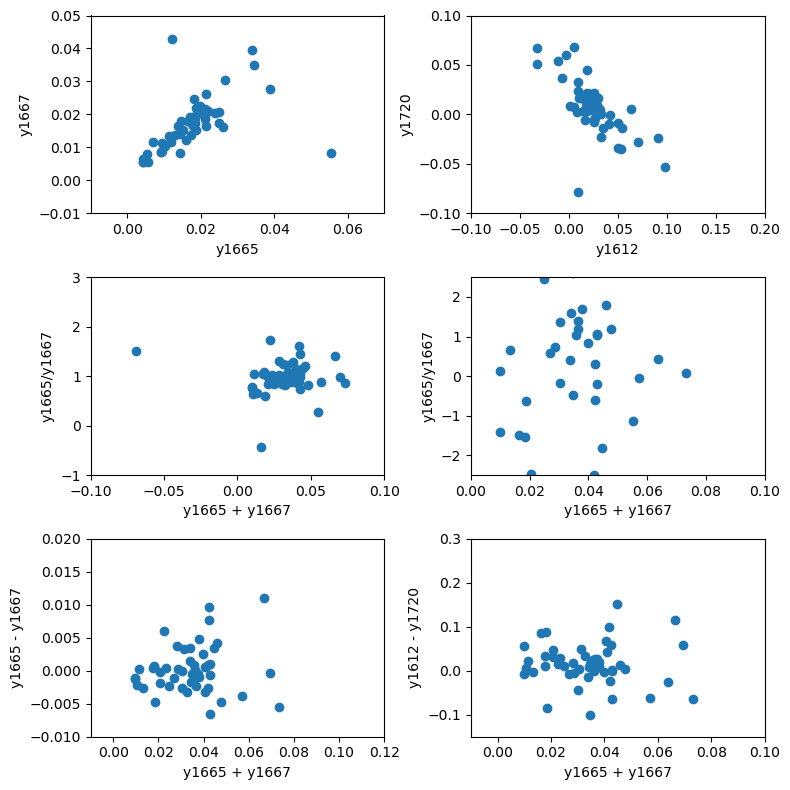

In [80]:
# Plot the data:
fig, axs = plt.subplots(3, 2, figsize=(8, 8))

# y1667 vs 1665
axs[0,0].scatter(hafner_y1665, hafner_y1667)
axs[0,0].set_xlabel('y1665')
axs[0,0].set_ylabel('y1667')
axs[0,0].set_xlim([-0.01, 0.07])
axs[0,0].set_ylim([-0.01, 0.05])

# y1612 vs y1720
axs[0,1].scatter(hafner_y1612, hafner_y1720)
axs[0,1].set_xlabel('y1612')
axs[0,1].set_ylabel('y1720')
axs[0,1].set_xlim([-0.1, 0.2])
axs[0,1].set_ylim([-0.1, 0.1])

# y1665/y1667 vs y1665 + y1667
axs[1,0].scatter(hafner_y1665+hafner_y1667, hafner_y1665/hafner_y1667)
axs[1,0].set_ylabel('y1665/y1667')
axs[1,0].set_xlabel('y1665 + y1667')
axs[1,0].set_xlim([-0.1, 0.1])
axs[1,0].set_ylim([-1, 3])

# y1612/y1720 vs y1665 + y1667
axs[1,1].scatter(hafner_y1665+hafner_y1667, hafner_y1612/hafner_y1720)
axs[1,1].set_ylabel('y1665/y1667')
axs[1,1].set_xlabel('y1665 + y1667')
axs[1,1].set_xlim([0, 0.1])
axs[1,1].set_ylim([-2.5, 2.5])

# y1665 - y1667 vs y1665 + y1667
axs[2,0].scatter(hafner_y1665+hafner_y1667, hafner_y1665 - hafner_y1667)
axs[2,0].set_ylabel('y1665 - y1667')
axs[2,0].set_xlabel('y1665 + y1667')
axs[2,0].set_xlim([-0.01, 0.12])
axs[2,0].set_ylim([-0.01, 0.02])

# y1665 - y1667 vs y1665 + y1667
axs[2,1].scatter(hafner_y1665+hafner_y1667, hafner_y1612 - hafner_y1720)
axs[2,1].set_ylabel('y1612 - y1720')
axs[2,1].set_xlabel('y1665 + y1667')
axs[2,1].set_xlim([-0.01, 0.1])
axs[2,1].set_ylim([-0.15, 0.3])

plt.tight_layout()
plt.show()

fig.savefig("HafnerMainSatteliteLineRelations.png")

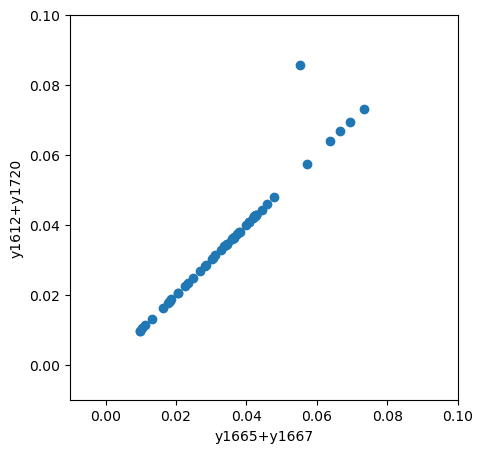

In [79]:
# Plot the data:
fig, axs = plt.subplots(1, 1, figsize=(5, 5))

# y1667 vs 1665
axs.scatter(hafner_y1665+hafner_y1667, hafner_y1612+hafner_y1720)
axs.set_xlabel('y1665+y1667')
axs.set_ylabel('y1612+y1720')
axs.set_xlim([-0.01, 0.1])
axs.set_ylim([-0.01, 0.1])

fig.savefig("HafnerSumRuleCheck.png")

In [ ]:
# Plot the data:
fig, axs = plt.subplots(1, 1, figsize=(5, 5))

# y1667 vs 1665
axs.scatter(hafner_y1665+hafner_y1667, hafner_y1612+hafner_y1720)
axs.set_xlabel('y1665+y1667')
axs.set_ylabel('y1612+y1720')
axs.set_xlim([-0.01, 0.1])
axs.set_ylim([-0.01, 0.1])

In [ ]:
# Write latex code:
#ascii.write(t, format='latex', latexdict={'tabletype': 'table*'})

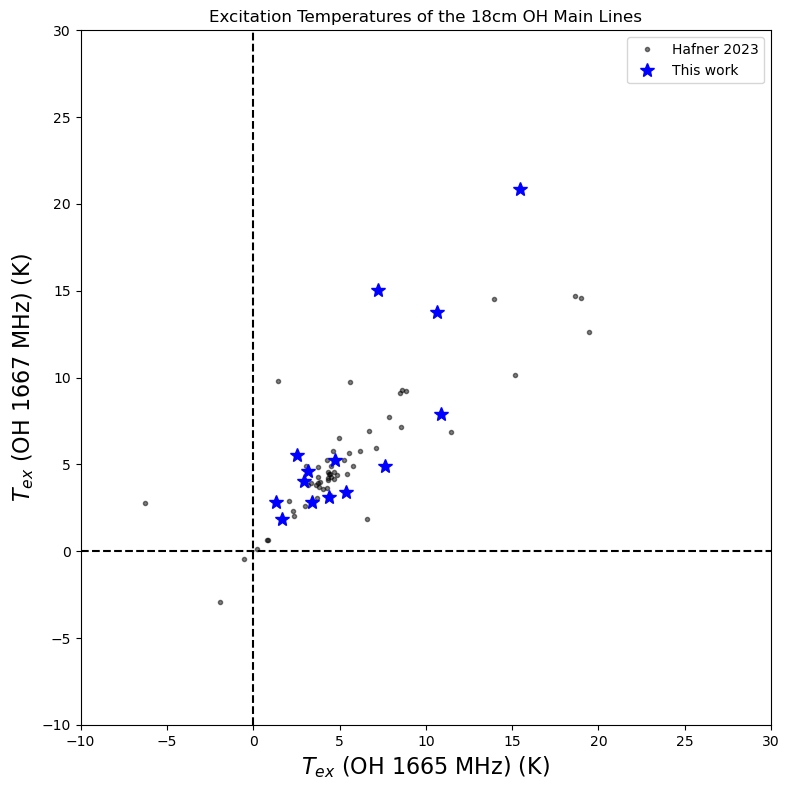

In [81]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
axs.errorbar(Tex_hafner['1665'], Tex_hafner['1667'], marker='.', ls='', alpha=0.5, color='k', label='Hafner 2023')
axs.errorbar(x=results[results.Line == 1665]['Tex'], y=results[results.Line == 1667]['Tex'], marker='*', markersize=10, color='blue', ls='', capsize=3, label='This work')
axs.axvline(0, color='k', ls='dashed')
axs.axhline(0, color='k', ls='dashed')
#axs.errorbar(x=6, y=5.1, yerr=0.2, xerr=0.5, marker='*', color='red', markersize=16, label='Engelke (W5) 2018')
axs.set_ylabel(r'$T_{ex}$ (OH 1667 MHz) (K)', size=16)
axs.set_xlabel(r'$T_{ex}$ (OH 1665 MHz) (K)', size=16)
axs.set_ylim([-10, 30])
axs.set_xlim([-10, 30])
axs.legend()
axs.set_title('Excitation Temperatures of the 18cm OH Main Lines')

fig.tight_layout()
#fig.savefig("Tex_firstDraft.pdf", format='pdf', dpi=400)
#fig.savefig("Tex_firstDraft.png", format='png', dpi=400)
#fig.savefig("Tex_IRonly_main.pdf", format='pdf', dpi=400)
#fig.savefig("Tex_IRonly_main.png", format='png', dpi=400)


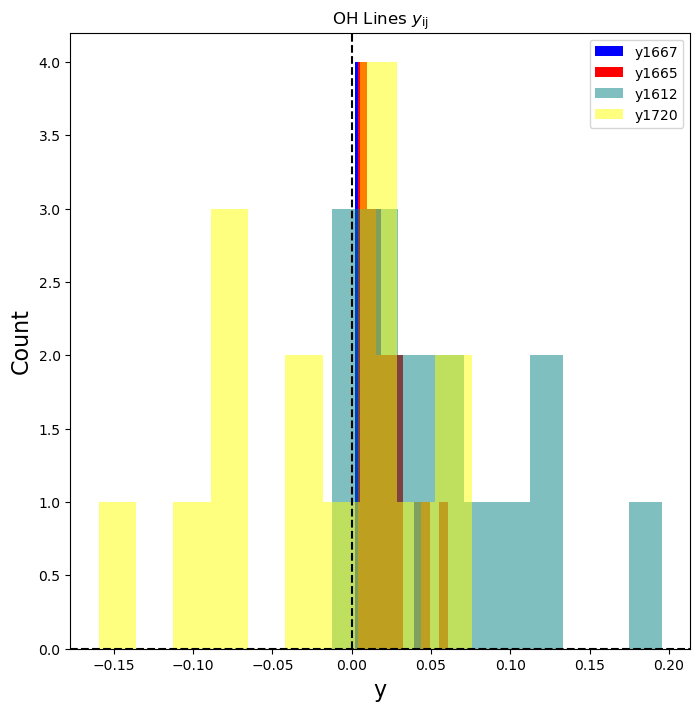

In [82]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
axs.hist(x=results[results.Line == 1667]['y'], alpha=1, color='blue', label='y1667')
axs.hist(x=results[results.Line == 1665]['y'], alpha=1, color='red', label='y1665')
axs.hist(x=results[results.Line == 1612]['y'], alpha=0.5, color='teal', label='y1612')
axs.hist(x=results[results.Line == 1720]['y'], alpha=0.5, color='yellow', label='y1720')
axs.legend()
axs.axvline(0, color='k', ls='dashed')
axs.axhline(0, color='k', ls='dashed')
axs.set_ylabel('Count', size=16)
axs.set_xlabel('y', size=16)
axs.set_title(r'OH Lines $y_{\mathrm{ij}}$')
fig.savefig("OH_y_hist.pdf", format='pdf', dpi=400)
fig.savefig("OH_y_hist.png", format='png', dpi=400)

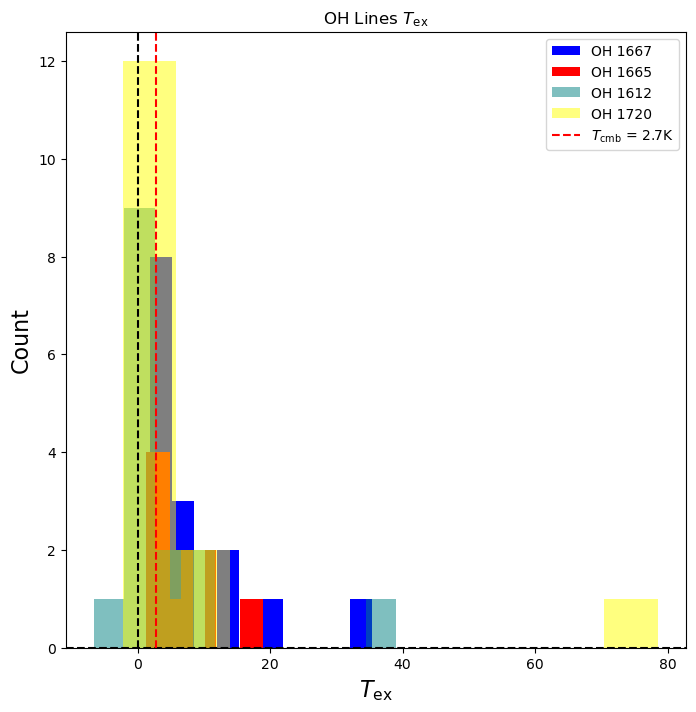

In [83]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
axs.hist(x=results[results.Line == 1667]['Tex'], alpha=1, color='blue', label='OH 1667')
axs.hist(x=results[results.Line == 1665]['Tex'], alpha=1, color='red', label='OH 1665')
axs.hist(x=results[results.Line == 1612]['Tex'], alpha=0.5, color='teal', label='OH 1612')
axs.hist(x=results[results.Line == 1720]['Tex'], alpha=0.5, color='yellow', label='OH 1720')
axs.axvline(0, color='k', ls='dashed')
axs.axhline(0, color='k', ls='dashed')
axs.axvline(2.7, color='r', ls='dashed', label=r'$T_{\mathrm{cmb}}$ = 2.7K')
axs.set_ylabel('Count', size=16)
axs.set_xlabel(r'$T_{\mathrm{ex}}$', size=16)
axs.set_title(r'OH Lines $T_{\mathrm{ex}}$')
axs.legend()
fig.savefig("OH_tex_hist.pdf", format='pdf', dpi=400)
fig.savefig("OH_tex_hist.png", format='png', dpi=400)

### 

Text(0.5, 0, '$T_{\\mathrm{ex, 1667}}$')

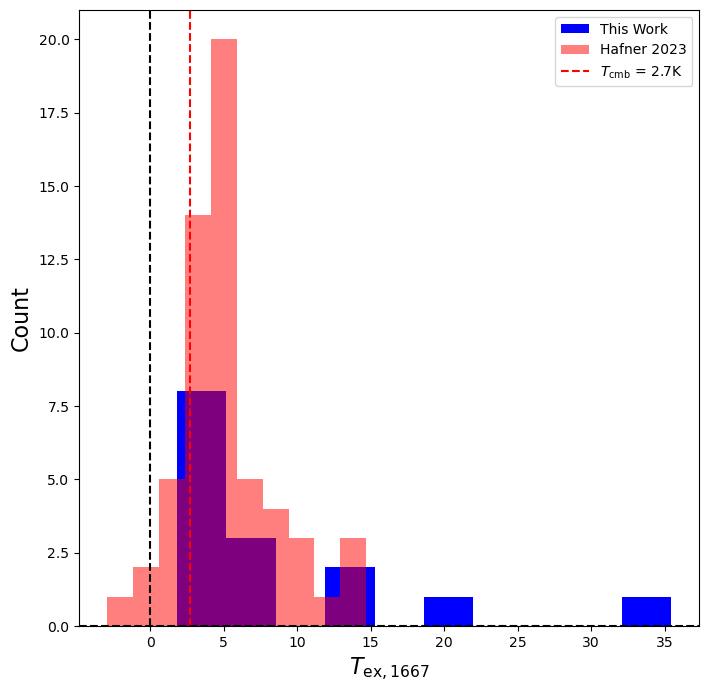

In [84]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
axs.hist(x=results[results.Line == 1667]['Tex'], color='blue', label='This Work')
axs.hist(x=Tex_hafner['1667'], alpha=0.5, color='red', label='Hafner 2023')
axs.axvline(2.7, color='r', ls='dashed', label=r'$T_{\mathrm{cmb}}$ = 2.7K')
axs.axvline(0, color='k', ls='dashed')
axs.axhline(0, color='k', ls='dashed')
axs.legend()
axs.set_ylabel('Count', size=16)
axs.set_xlabel(r'$T_{\mathrm{ex, 1667}}$', size=16)

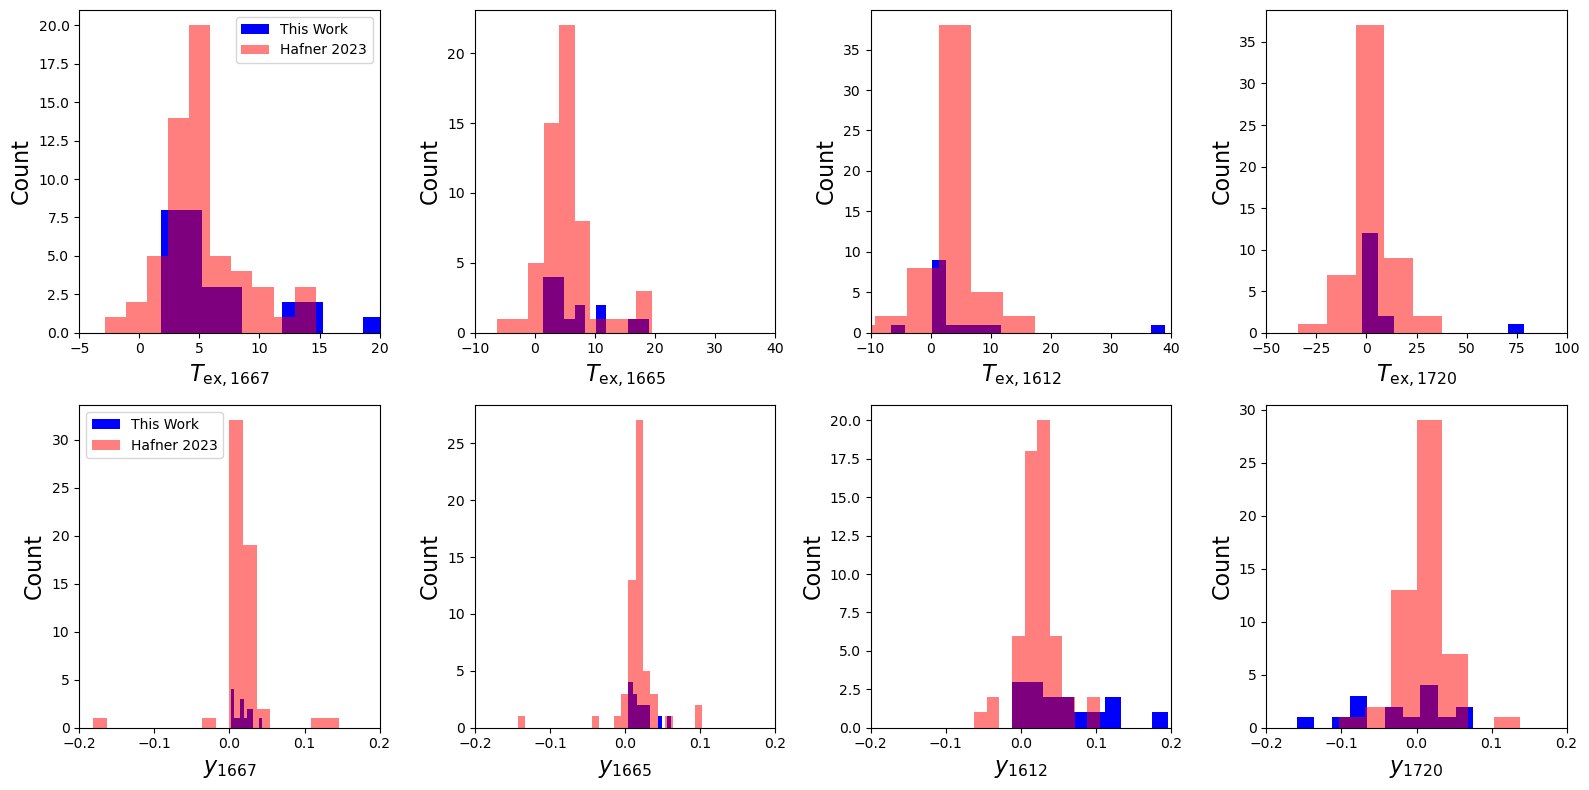

In [183]:
# Plot the histograms of Tex, y:
fig, axs = plt.subplots(2, 4, figsize=(16, 8))

# Plot the OH Tex's:
axs[0,0].hist(x=results[results.Line == 1667]['Tex'], color='blue', label='This Work')
axs[0,0].hist(x=Tex_hafner['1667'], alpha=0.5, color='red', label='Hafner 2023')
axs[0,0].legend()
axs[0,0].set_ylabel('Count', size=16)
axs[0,0].set_xlabel(r'$T_{\mathrm{ex, 1667}}$', size=16)
axs[0,0].set_xlim([-5, 20])

axs[0,1].hist(x=results[results.Line == 1665]['Tex'], color='blue')
axs[0,1].hist(x=Tex_hafner['1665'], alpha=0.5, color='red')
axs[0,1].set_ylabel('Count', size=16)
axs[0,1].set_xlabel(r'$T_{\mathrm{ex, 1665}}$', size=16)
axs[0,1].set_xlim([-10, 40])

axs[0,2].hist(bins=20, x=results[results.Line == 1612]['Tex'], color='blue')
axs[0,2].hist(bins=20, x=Tex_hafner['1612'], alpha=0.5, color='red')
axs[0,2].set_ylabel('Count', size=16)
axs[0,2].set_xlabel(r'$T_{\mathrm{ex, 1612}}$', size=16)
axs[0,2].set_xlim([-10, 40])

axs[0,3].hist(bins=10, x=results[results.Line == 1720]['Tex'], color='blue')
axs[0,3].hist(bins=200, x=Tex_hafner['1720'], alpha=0.5, color='red')
axs[0,3].set_ylabel('Count', size=16)
axs[0,3].set_xlabel(r'$T_{\mathrm{ex, 1720}}$', size=16)
axs[0,3].set_xlim([-50, 100])

# ys of the data set:
axs[1,0].hist(bins=10, x=results[results.Line == 1667]['y'], color='blue', label='This Work')
axs[1,0].hist(bins=50, x=hafner_y1667, alpha=0.5, color='red', label='Hafner 2023')
axs[1,0].legend()
axs[1,0].set_ylabel('Count', size=16)
axs[1,0].set_xlabel(r'$y_{\mathrm{1667}}$', size=16)
axs[1,0].set_xlim([-0.2, 0.2])

axs[1,1].hist(bins=10, x=results[results.Line == 1665]['y'], color='blue')
axs[1,1].hist(bins=50, x=hafner_y1665, alpha=0.5, color='red')
axs[1,1].set_ylabel('Count', size=16)
axs[1,1].set_xlabel(r'$y_{\mathrm{1665}}$', size=16)
axs[1,1].set_xlim([-0.2, 0.2])

axs[1,2].hist(bins=10, x=results[results.Line == 1612]['y'], color='blue')
axs[1,2].hist(bins=50, x=hafner_y1612, alpha=0.5, color='red')
axs[1,2].set_ylabel('Count', size=16)
axs[1,2].set_xlabel(r'$y_{\mathrm{1612}}$', size=16)
axs[1,2].set_xlim([-0.2, 0.2])

axs[1,3].hist(bins=10, x=results[results.Line == 1720]['y'], color='blue')
axs[1,3].hist(bins=50, x=hafner_y1720, alpha=0.5, color='red')
axs[1,3].set_ylabel('Count', size=16)
axs[1,3].set_xlabel(r'$y_{\mathrm{1720}}$', size=16)
axs[1,3].set_xlim([-0.2, 0.2])

fig.tight_layout()

fig.savefig("histograms_2026.png", format='png')
fig.savefig("histograms_2026.pdf", format='pdf')

Text(0.5, 0, '$T_{\\mathrm{ex, 1665}}$')

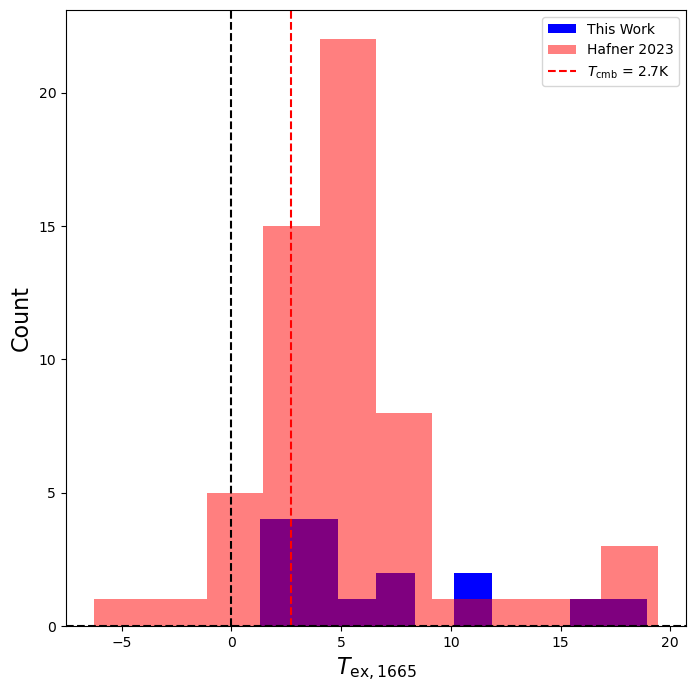

In [134]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
axs.hist(x=results[results.Line == 1665]['Tex'], color='blue', label='This Work')
axs.hist(x=Tex_hafner['1665'], alpha=0.5, color='red', label='Hafner 2023')
axs.axvline(2.7, color='r', ls='dashed', label=r'$T_{\mathrm{cmb}}$ = 2.7K')
axs.axvline(0, color='k', ls='dashed')
axs.axhline(0, color='k', ls='dashed')
axs.legend()
axs.set_ylabel('Count', size=16)
axs.set_xlabel(r'$T_{\mathrm{ex, 1665}}$', size=16)

In [135]:
# Y main lines, error determination.
ymain_plus = results[results.Line == 1665]['y'].to_numpy()+results[results.Line == 1667]['y'].to_numpy() 
ymain_minus = results[results.Line == 1665]['y'].to_numpy()-results[results.Line == 1667]['y'].to_numpy() 
ymain_plus_err = np.sqrt(results[results.Line == 1665]['\sigma y'].to_numpy()**2+results[results.Line == 1667]['\sigma y'].to_numpy()**2)

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_524/554864734.py:4: SyntaxWarning: invalid escape sequence '\s'
  ymain_plus_err = np.sqrt(results[results.Line == 1665]['\sigma y'].to_numpy()**2+results[results.Line == 1667]['\sigma y'].to_numpy()**2)
/tmp/ipykernel_524/554864734.py:4: SyntaxWarning: invalid escape sequence '\s'
  ymain_plus_err = np.sqrt(results[results.Line == 1665]['\sigma y'].to_numpy()**2+results[results.Line == 1667]['\sigma y'].to_numpy()**2)


In [136]:
# Y satellites, error determination.
ysat_minus = results[results.Line == 1612]['y'].to_numpy()-results[results.Line == 1720]['y'].to_numpy() 
ysat_plus = results[results.Line == 1612]['y'].to_numpy()-results[results.Line == 1720]['y'].to_numpy() 
ysat_minus_err = np.sqrt(results[results.Line == 1612]['\sigma y'].to_numpy()**2+results[results.Line == 1720]['\sigma y'].to_numpy()**2)

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_524/1525429693.py:4: SyntaxWarning: invalid escape sequence '\s'
  ysat_minus_err = np.sqrt(results[results.Line == 1612]['\sigma y'].to_numpy()**2+results[results.Line == 1720]['\sigma y'].to_numpy()**2)
/tmp/ipykernel_524/1525429693.py:4: SyntaxWarning: invalid escape sequence '\s'
  ysat_minus_err = np.sqrt(results[results.Line == 1612]['\sigma y'].to_numpy()**2+results[results.Line == 1720]['\sigma y'].to_numpy()**2)


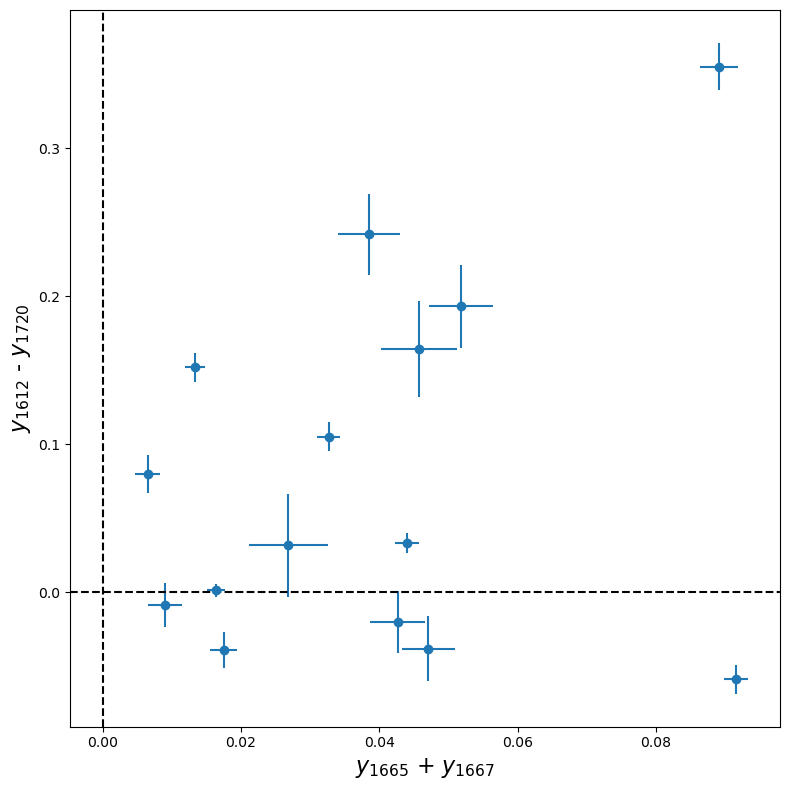

In [137]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
axs.errorbar(x=ymain_plus, y=ysat_minus, yerr=ysat_minus_err, xerr=ymain_plus_err, ls='', marker='o')
axs.axvline(0, color='k', ls='dashed')
axs.axhline(0, color='k', ls='dashed')
#axs.errorbar(x=6, y=5.1, yerr=0.2, xerr=0.5, marker='*', color='red', markersize=14, label='Engelke (W5) 2018')
axs.set_ylabel(r'$y_{1612}$ - $y_{1720}$', size=16)
axs.set_xlabel(r'$y_{1665}$ + $y_{1667}$', size=16)
#axs.set_ylim([-0.4, 0.6])
#axs.set_xlim([-0.04, 0.12])
#axs.legend()
#axs.set_title(r'Inverse $T_{\mathrm{ex}}$ of the 18cm OH Main Lines')

fig.tight_layout()
fig.savefig("Diff_of_Ysat.pdf", format='pdf', dpi=400)
fig.savefig("Diff_of_Ysat.png", format='png', dpi=400)

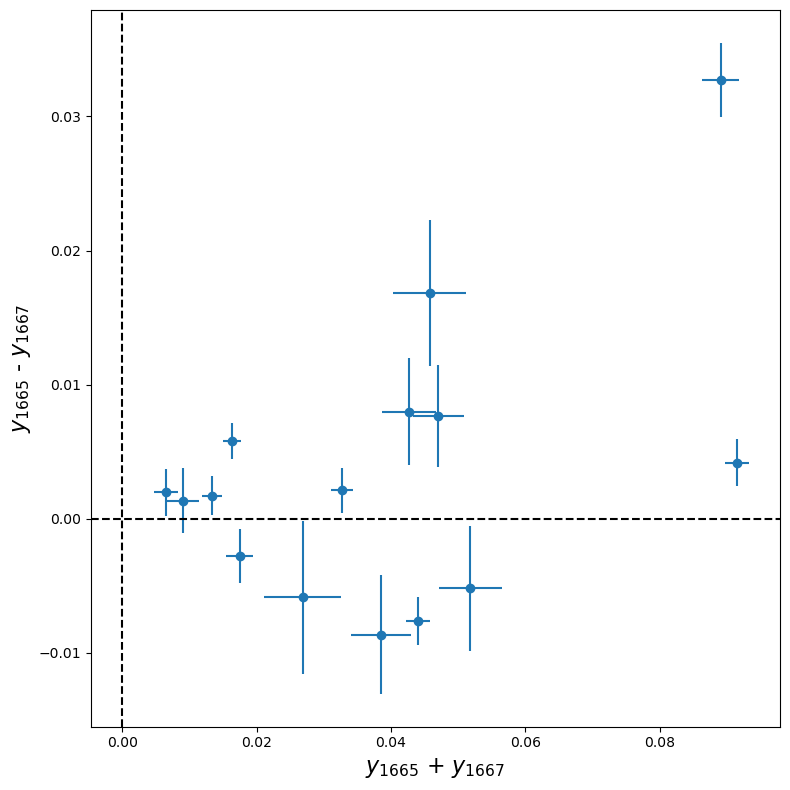

In [138]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
axs.errorbar(x=ymain_plus, y=ymain_minus, yerr=ymain_plus_err, xerr=ymain_plus_err, ls='', marker='o')
axs.axvline(0, color='k', ls='dashed')
axs.axhline(0, color='k', ls='dashed')
#axs.errorbar(x=6, y=5.1, yerr=0.2, xerr=0.5, marker='*', color='red', markersize=14, label='Engelke (W5) 2018')
axs.set_ylabel(r'$y_{1665}$ - $y_{1667}$', size=16)
axs.set_xlabel(r'$y_{1665}$ + $y_{1667}$', size=16)
#axs.set_ylim([-0.4, 0.6])
#axs.set_xlim([-0.04, 0.12])
#axs.legend()
#axs.set_title(r'Inverse $T_{\mathrm{ex}}$ of the 18cm OH Main Lines')

fig.tight_layout()
fig.savefig("Diff_of_Ymain.pdf", format='pdf', dpi=400)
fig.savefig("Diff_of_Ymain.png", format='png', dpi=400)

In [139]:
results

,Source,Component,Line,W,\sigma W,Center,\sigma Center,FWHM,\sigma FWHM,N(OH)_fit,\sigma N(OH)_fit,Tex,\sigma Tex,1/Tex,\sigma 1/Tex,y,\sigma y
0,W51,0,1667,-0.101267,0.009641,6.313815,0.095215,3.048439,0.197999,7.638107e+13,3.376555e+12,3.394137,0.323140,0.294626,0.030926,0.023576,0.002245
1,W51,0,1665,-0.035632,0.009137,6.313815,0.095215,3.048439,0.197999,7.638107e+13,3.376555e+12,5.358991,1.374133,0.186602,0.048554,0.014932,0.003829
2,W51,0,1612,-0.062720,0.009288,6.313815,0.095215,3.048439,0.197999,7.638107e+13,3.376555e+12,0.608903,0.090174,1.642297,0.253817,0.131418,0.019462
3,W51,0,1720,0.052752,0.009223,6.313815,0.095215,3.048439,0.197999,7.638107e+13,3.376555e+12,-0.723963,0.126573,-1.381287,0.249095,-0.110531,0.019325
4,W51,0,316,-2.002854,0.153354,6.313815,0.095215,3.048439,0.197999,7.638107e+13,3.376555e+12,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,W49N2,0,1612,-0.098828,0.024069,39.194896,0.197511,4.279673,0.457321,1.667959e+14,1.132381e+13,0.843872,0.205519,1.185013,0.299605,0.094825,0.023094
101,W49N2,0,1720,0.072562,0.023800,39.194896,0.197511,4.279673,0.457321,1.667959e+14,1.132381e+13,-1.149335,0.376981,-0.870068,0.291431,-0.069623,0.022836
102,W49N2,0,316,-4.373699,0.514298,39.194896,0.197511,4.279673,0.457321,1.667959e+14,1.132381e+13,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
103,W49N2,0,298,-0.310533,0.036515,41.264896,0.197511,4.279673,0.457321,1.667959e+14,1.132381e+13,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


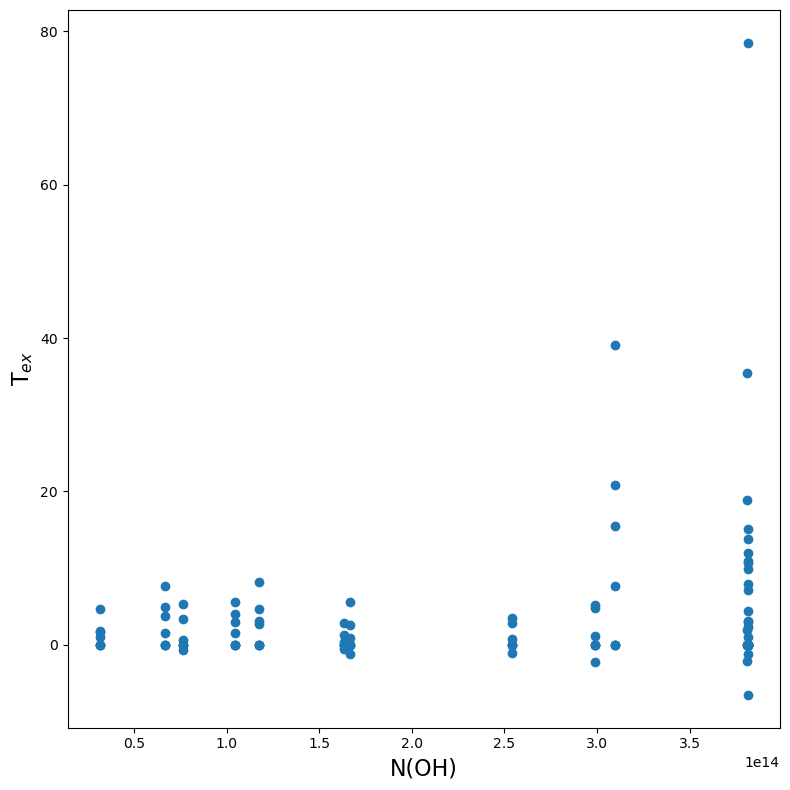

In [140]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
axs.scatter(x=results['N(OH)_fit'], y=results['Tex'], marker='o')
#axs.errorbar(x=6, y=5.1, yerr=0.2, xerr=0.5, marker='*', color='red', markersize=14, label='Engelke (W5) 2018')
axs.set_ylabel(r'T$_{ex}$', size=16)
axs.set_xlabel(r'N(OH)', size=16)
#axs.set_ylim([-0.4, 0.6])
#axs.set_xlim([-0.04, 0.12])
#axs.legend()
#axs.set_title(r'Inverse $T_{\mathrm{ex}}$ of the 18cm OH Main Lines')

fig.tight_layout()
#fig.savefig("Diff_of_Ysat.pdf", format='pdf', dpi=400)
#fig.savefig("Diff_of_Ysat.png", format='png', dpi=400)

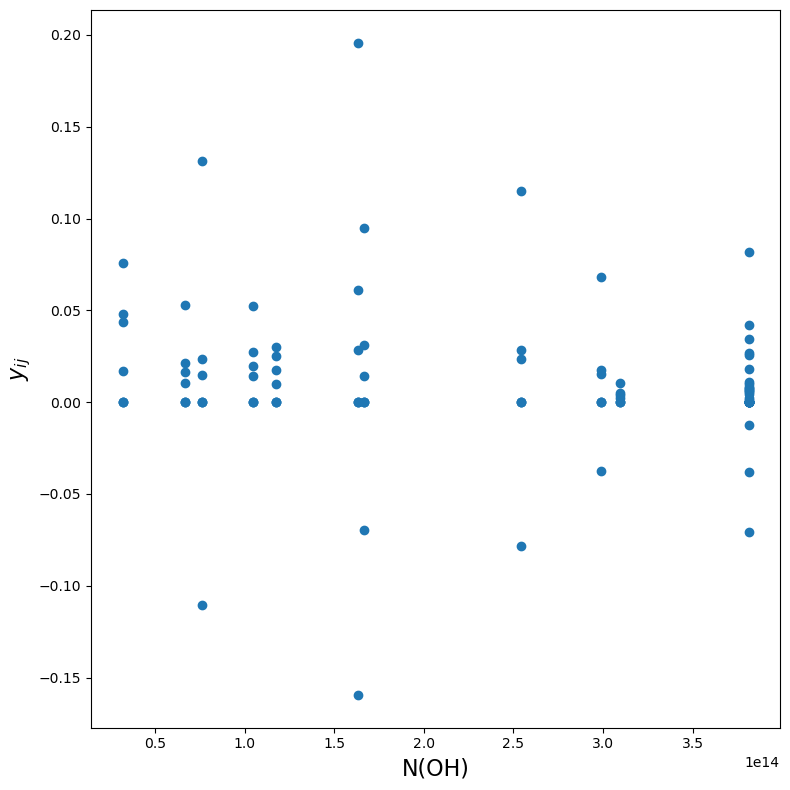

In [141]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
axs.scatter(x=results['N(OH)_fit'], y=results['y'], marker='o')
#axs.errorbar(x=6, y=5.1, yerr=0.2, xerr=0.5, marker='*', color='red', markersize=14, label='Engelke (W5) 2018')
axs.set_ylabel(r'$y_{ij}$', size=16)
axs.set_xlabel(r'N(OH)', size=16)
#axs.set_ylim([-0.4, 0.6])
#axs.set_xlim([-0.04, 0.12])
#axs.legend()
#axs.set_title(r'Inverse $T_{\mathrm{ex}}$ of the 18cm OH Main Lines')

fig.tight_layout()
#fig.savefig("Diff_of_Ysat.pdf", format='pdf', dpi=400)
#fig.savefig("Diff_of_Ysat.png", format='png', dpi=400)

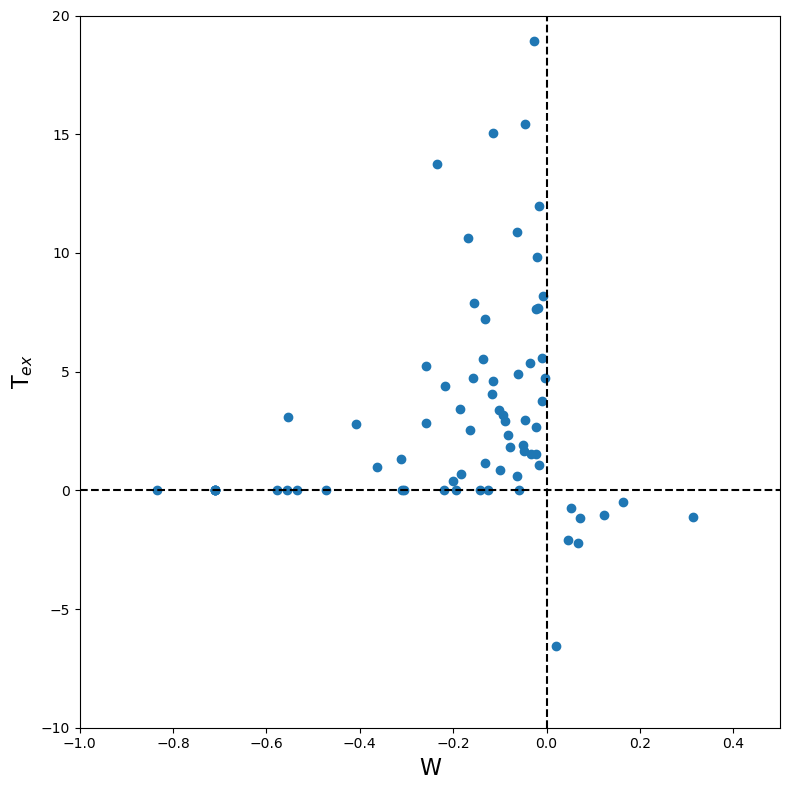

In [142]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
axs.scatter(x=results['W'], y=results['Tex'], marker='o')
#axs.errorbar(x=6, y=5.1, yerr=0.2, xerr=0.5, marker='*', color='red', markersize=14, label='Engelke (W5) 2018')
axs.set_ylabel(r'T$_{ex}$', size=16)
axs.set_xlabel(r'W', size=16)
axs.set_ylim([-10, 20])
axs.set_xlim([-1, 0.5])
axs.axvline(0, color='k', ls='dashed')
axs.axhline(0, color='k', ls='dashed')
#axs.legend()
#axs.set_title(r'Inverse $T_{\mathrm{ex}}$ of the 18cm OH Main Lines')

fig.tight_layout()
#fig.savefig("Diff_of_Ysat.pdf", format='pdf', dpi=400)
#fig.savefig("Diff_of_Ysat.png", format='png', dpi=400)

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_524/2822234248.py:5: SyntaxWarning: invalid escape sequence '\s'
  axs.errorbar(y=results[results.Line == 1667]['y'], yerr=results[results.Line == 1667]['\sigma y'], x=results[results.L

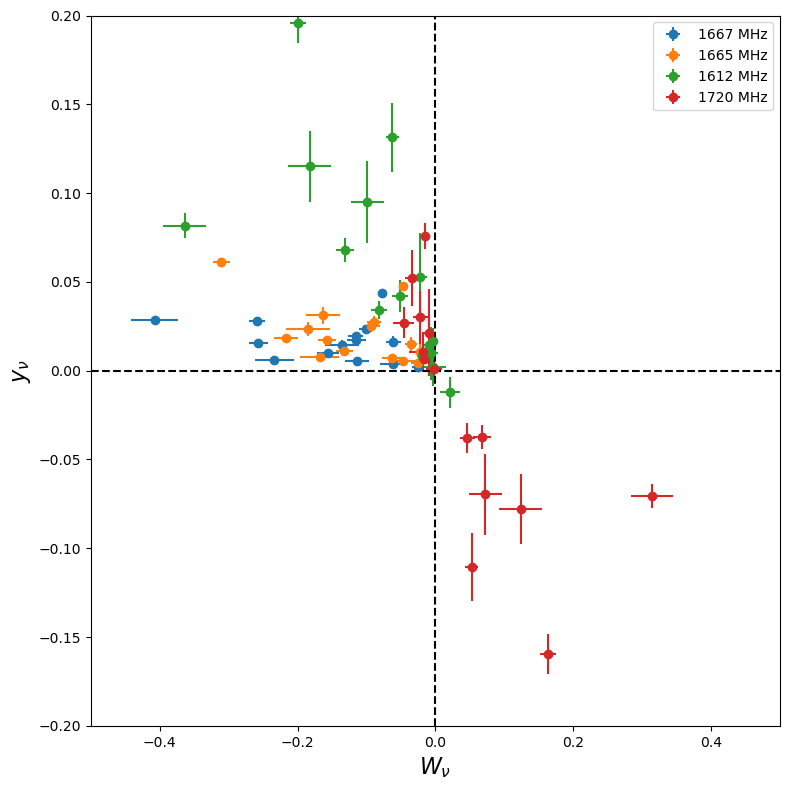

In [167]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
axs.errorbar(y=results[results.Line == 1667]['y'], yerr=results[results.Line == 1667]['\sigma y'], x=results[results.Line == 1667]['W'], xerr=results[results.Line == 1667]['\sigma W'], marker='o', ls='None', label='1667 MHz')
axs.errorbar(y=results[results.Line == 1665]['y'], yerr=results[results.Line == 1665]['\sigma y'], x=results[results.Line == 1665]['W'], xerr=results[results.Line == 1665]['\sigma W'], marker='o', ls='None', label='1665 MHz')
axs.errorbar(y=results[results.Line == 1612]['y'], yerr=results[results.Line == 1612]['\sigma y'], x=results[results.Line == 1612]['W'], xerr=results[results.Line == 1612]['\sigma W'], marker='o', ls='None', label='1612 MHz')
axs.errorbar(y=results[results.Line == 1720]['y'], yerr=results[results.Line == 1720]['\sigma y'], x=results[results.Line == 1720]['W'], xerr=results[results.Line == 1720]['\sigma W'], marker='o', ls='None', label='1720 MHz')
#axs.errorbar(x=6, y=5.1, yerr=0.2, xerr=0.5, marker='*', color='red', markersize=14, label='Engelke (W5) 2018')
axs.set_ylabel(r'$y_{\nu}$', size=16)
axs.set_xlabel(r'$W_{\nu}$', size=16)
axs.set_ylim([-0.2, 0.2])
axs.set_xlim([-0.5, 0.5])
axs.axvline(0, color='k', ls='dashed')
axs.axhline(0, color='k', ls='dashed')
axs.legend()
#axs.set_title(r'Inverse $T_{\mathrm{ex}}$ of the 18cm OH Main Lines')

fig.tight_layout()
fig.savefig("YvsW.pdf", format='pdf', dpi=400)
fig.savefig("YvsW.png", format='png', dpi=400)

In [179]:
results

,Source,Component,Line,W,\sigma W,Center,\sigma Center,FWHM,\sigma FWHM,N(OH)_fit,\sigma N(OH)_fit,Tex,\sigma Tex,1/Tex,\sigma 1/Tex,y,\sigma y
0,W51,0,1667,-0.101267,0.009641,6.313815,0.095215,3.048439,0.197999,7.638107e+13,3.376555e+12,3.394137,0.323140,0.294626,0.030926,0.023576,0.002245
1,W51,0,1665,-0.035632,0.009137,6.313815,0.095215,3.048439,0.197999,7.638107e+13,3.376555e+12,5.358991,1.374133,0.186602,0.048554,0.014932,0.003829
2,W51,0,1612,-0.062720,0.009288,6.313815,0.095215,3.048439,0.197999,7.638107e+13,3.376555e+12,0.608903,0.090174,1.642297,0.253817,0.131418,0.019462
3,W51,0,1720,0.052752,0.009223,6.313815,0.095215,3.048439,0.197999,7.638107e+13,3.376555e+12,-0.723963,0.126573,-1.381287,0.249095,-0.110531,0.019325
4,W51,0,316,-2.002854,0.153354,6.313815,0.095215,3.048439,0.197999,7.638107e+13,3.376555e+12,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,W49N2,0,1612,-0.098828,0.024069,39.194896,0.197511,4.279673,0.457321,1.667959e+14,1.132381e+13,0.843872,0.205519,1.185013,0.299605,0.094825,0.023094
101,W49N2,0,1720,0.072562,0.023800,39.194896,0.197511,4.279673,0.457321,1.667959e+14,1.132381e+13,-1.149335,0.376981,-0.870068,0.291431,-0.069623,0.022836
102,W49N2,0,316,-4.373699,0.514298,39.194896,0.197511,4.279673,0.457321,1.667959e+14,1.132381e+13,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
103,W49N2,0,298,-0.310533,0.036515,41.264896,0.197511,4.279673,0.457321,1.667959e+14,1.132381e+13,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_524/419432650.py:5: SyntaxWarning: invalid escape sequence '\s'
  axs.errorbar(y=results[results.Line == 1667]['y'], yerr=results[results.Line == 1667]['\sigma y'], x=results[results.Li

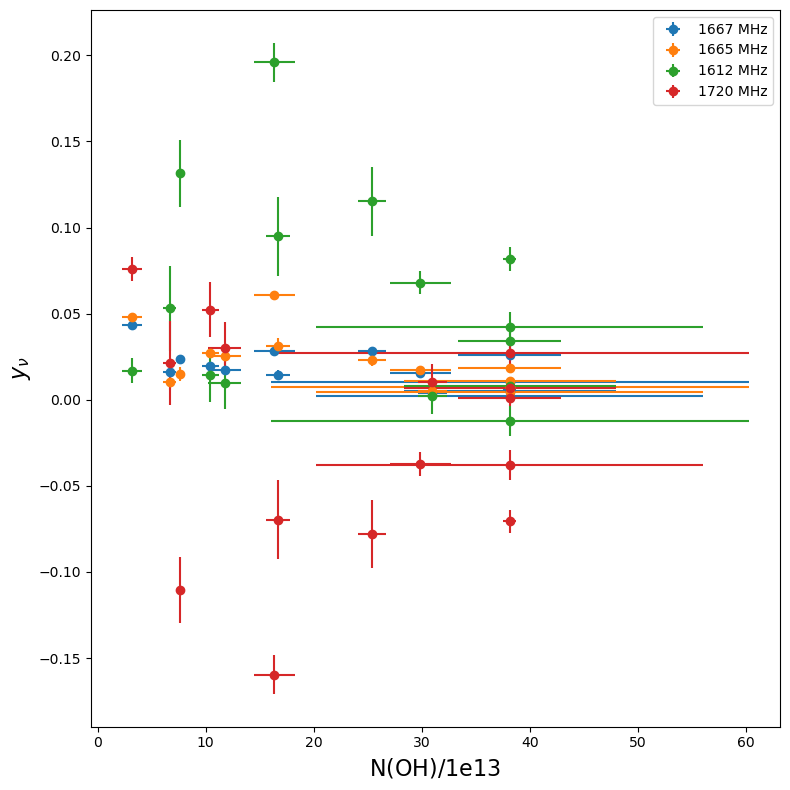

In [182]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
axs.errorbar(y=results[results.Line == 1667]['y'], yerr=results[results.Line == 1667]['\sigma y'], x=results[results.Line == 1667]['N(OH)_fit']/1e13, xerr=results[results.Line == 1667]['\sigma N(OH)_fit']/1e13, marker='o', ls='None', label='1667 MHz')
axs.errorbar(y=results[results.Line == 1665]['y'], yerr=results[results.Line == 1665]['\sigma y'], x=results[results.Line == 1665]['N(OH)_fit']/1e13, xerr=results[results.Line == 1665]['\sigma N(OH)_fit']/1e13, marker='o', ls='None', label='1665 MHz')
axs.errorbar(y=results[results.Line == 1612]['y'], yerr=results[results.Line == 1612]['\sigma y'], x=results[results.Line == 1612]['N(OH)_fit']/1e13, xerr=results[results.Line == 1612]['\sigma N(OH)_fit']/1e13, marker='o', ls='None', label='1612 MHz')
axs.errorbar(y=results[results.Line == 1720]['y'], yerr=results[results.Line == 1720]['\sigma y'], x=results[results.Line == 1720]['N(OH)_fit']/1e13, xerr=results[results.Line == 1720]['\sigma N(OH)_fit']/1e13, marker='o', ls='None', label='1720 MHz')
#axs.errorbar(x=6, y=5.1, yerr=0.2, xerr=0.5, marker='*', color='red', markersize=14, label='Engelke (W5) 2018')
axs.set_ylabel(r'$y_{\nu}$', size=16)
axs.set_xlabel(r'N$(\rm OH)$/1e13', size=16)
axs.legend()
#axs.set_title(r'Inverse $T_{\mathrm{ex}}$ of the 18cm OH Main Lines')

fig.tight_layout()
fig.savefig("YvsNOH.pdf", format='pdf', dpi=400)
fig.savefig("YvsNOH.png", format='png', dpi=400)

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid e

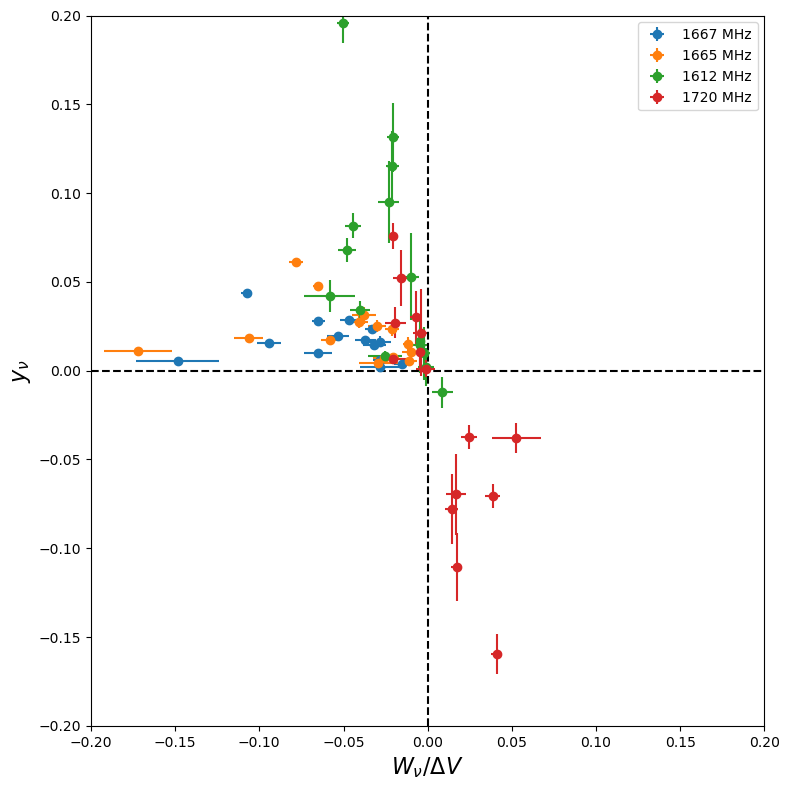

In [14]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Values:
wdeltav_1667 = results[results.Line == 1667]['W']/results[results.Line == 1667]['FWHM']
wdeltav_1665 = results[results.Line == 1665]['W']/results[results.Line == 1665]['FWHM']
wdeltav_1612 = results[results.Line == 1612]['W']/results[results.Line == 1612]['FWHM']
wdeltav_1720 = results[results.Line == 1720]['W']/results[results.Line == 1720]['FWHM']

# Error:
wdeltav_err_1667 = np.abs(results[results.Line == 1667]['W']/results[results.Line == 1667]['FWHM'])*np.sqrt((results[results.Line == 1667]['\sigma W']/results[results.Line == 1667]['W'])**2 + (results[results.Line == 1667]['\sigma FWHM']/results[results.Line == 1667]['FWHM'])**2)
wdeltav_err_1665 = np.abs(results[results.Line == 1665]['W']/results[results.Line == 1665]['FWHM'])*np.sqrt((results[results.Line == 1665]['\sigma W']/results[results.Line == 1665]['W'])**2 + (results[results.Line == 1665]['\sigma FWHM']/results[results.Line == 1665]['FWHM'])**2)
wdeltav_err_1612 = np.abs(results[results.Line == 1612]['W']/results[results.Line == 1612]['FWHM'])*np.sqrt((results[results.Line == 1612]['\sigma W']/results[results.Line == 1612]['W'])**2 + (results[results.Line == 1612]['\sigma FWHM']/results[results.Line == 1612]['FWHM'])**2)
wdeltav_err_1720 = np.abs(results[results.Line == 1720]['W']/results[results.Line == 1720]['FWHM'])*np.sqrt((results[results.Line == 1720]['\sigma W']/results[results.Line == 1720]['W'])**2 + (results[results.Line == 1720]['\sigma FWHM']/results[results.Line == 1720]['FWHM'])**2)

# Plot the OH:
axs.errorbar(y=results[results.Line == 1667]['y'], yerr=results[results.Line == 1667]['\sigma y'], x=wdeltav_1667, xerr=wdeltav_err_1667, marker='o', ls='None', label='1667 MHz')
axs.errorbar(y=results[results.Line == 1665]['y'], yerr=results[results.Line == 1665]['\sigma y'], x=wdeltav_1665, xerr=wdeltav_err_1665, marker='o', ls='None', label='1665 MHz')
axs.errorbar(y=results[results.Line == 1612]['y'], yerr=results[results.Line == 1612]['\sigma y'], x=wdeltav_1612, xerr=wdeltav_err_1612, marker='o', ls='None', label='1612 MHz')
axs.errorbar(y=results[results.Line == 1720]['y'], yerr=results[results.Line == 1720]['\sigma y'], x=wdeltav_1720, xerr=wdeltav_err_1720, marker='o', ls='None', label='1720 MHz')
#axs.errorbar(x=6, y=5.1, yerr=0.2, xerr=0.5, marker='*', color='red', markersize=14, label='Engelke (W5) 2018')
axs.set_ylabel(r'$y_{\nu}$', size=16)
axs.set_xlabel(r'$W_{\nu}/\Delta V$', size=16)
axs.set_ylim([-0.2, 0.2])
axs.set_xlim([-0.2, 0.2])
axs.axvline(0, color='k', ls='dashed')
axs.axhline(0, color='k', ls='dashed')
axs.legend()
#axs.set_title(r'Inverse $T_{\mathrm{ex}}$ of the 18cm OH Main Lines')

fig.tight_layout()
#fig.savefig("Diff_of_Ysat.pdf", format='pdf', dpi=400)
#fig.savefig("Diff_of_Ysat.png", format='png', dpi=400)

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '

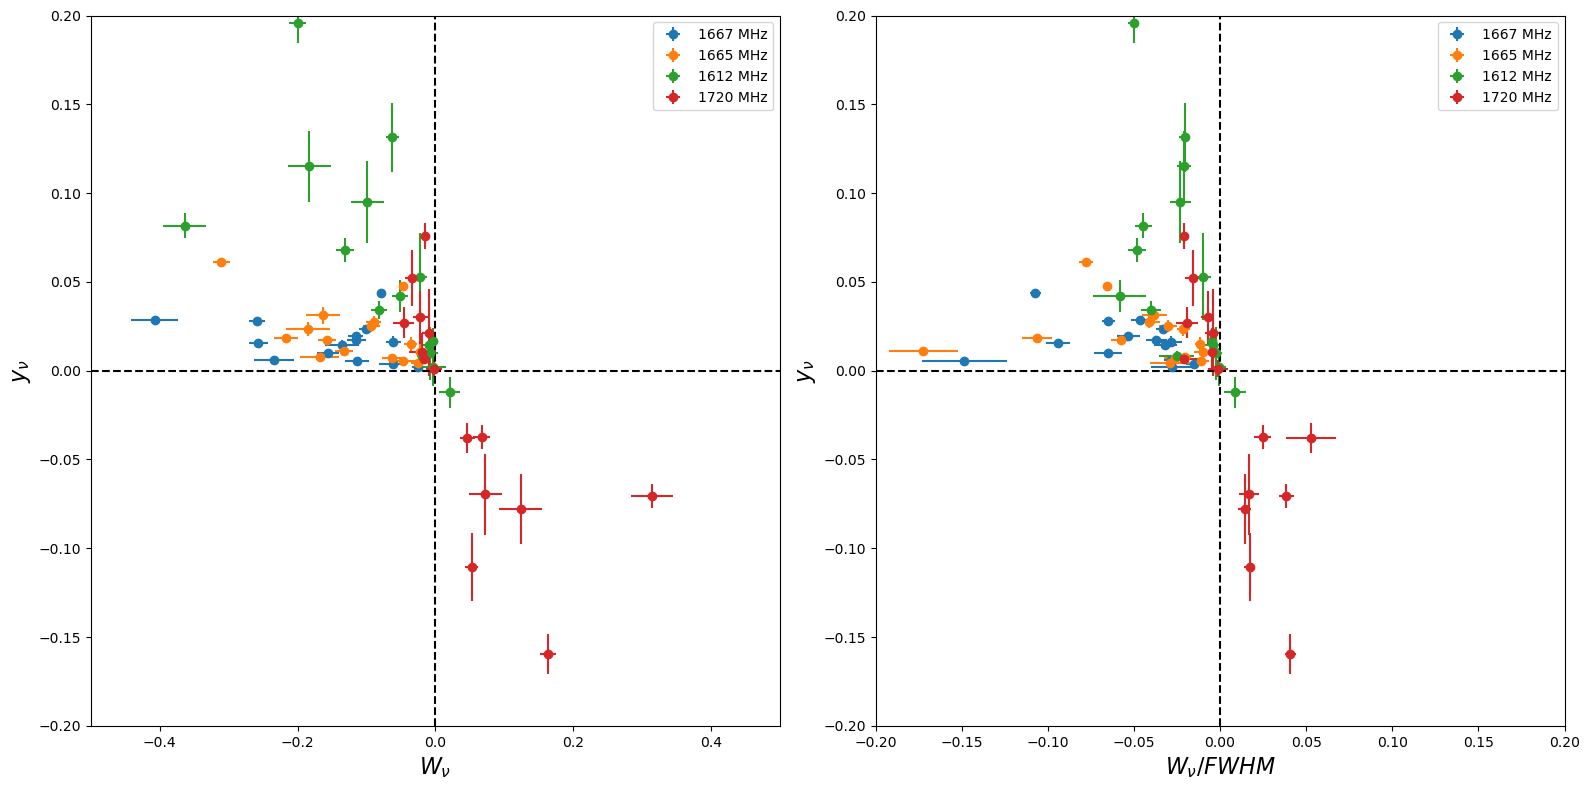

In [15]:
# Plot the data:
fig, axs = plt.subplots(1,2, figsize=(16, 8))

# Plot y vs Wv:
axs[0].errorbar(y=results[results.Line == 1667]['y'], yerr=results[results.Line == 1667]['\sigma y'], x=results[results.Line == 1667]['W'], xerr=results[results.Line == 1667]['\sigma W'], marker='o', ls='None', label='1667 MHz')
axs[0].errorbar(y=results[results.Line == 1665]['y'], yerr=results[results.Line == 1665]['\sigma y'], x=results[results.Line == 1665]['W'], xerr=results[results.Line == 1665]['\sigma W'], marker='o', ls='None', label='1665 MHz')
axs[0].errorbar(y=results[results.Line == 1612]['y'], yerr=results[results.Line == 1612]['\sigma y'], x=results[results.Line == 1612]['W'], xerr=results[results.Line == 1612]['\sigma W'], marker='o', ls='None', label='1612 MHz')
axs[0].errorbar(y=results[results.Line == 1720]['y'], yerr=results[results.Line == 1720]['\sigma y'], x=results[results.Line == 1720]['W'], xerr=results[results.Line == 1720]['\sigma W'], marker='o', ls='None', label='1720 MHz')
#axs.errorbar(x=6, y=5.1, yerr=0.2, xerr=0.5, marker='*', color='red', markersize=14, label='Engelke (W5) 2018')
axs[0].set_ylabel(r'$y_{\nu}$', size=16)
axs[0].set_xlabel(r'$W_{\nu}$', size=16)
axs[0].set_ylim([-0.2, 0.2])
axs[0].set_xlim([-0.5, 0.5])
axs[0].axvline(0, color='k', ls='dashed')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].legend()

# Plot y vs Wv/deltaV:
axs[1].errorbar(y=results[results.Line == 1667]['y'], yerr=results[results.Line == 1667]['\sigma y'], x=wdeltav_1667, xerr=wdeltav_err_1667, marker='o', ls='None', label='1667 MHz')
axs[1].errorbar(y=results[results.Line == 1665]['y'], yerr=results[results.Line == 1665]['\sigma y'], x=wdeltav_1665, xerr=wdeltav_err_1665, marker='o', ls='None', label='1665 MHz')
axs[1].errorbar(y=results[results.Line == 1612]['y'], yerr=results[results.Line == 1612]['\sigma y'], x=wdeltav_1612, xerr=wdeltav_err_1612, marker='o', ls='None', label='1612 MHz')
axs[1].errorbar(y=results[results.Line == 1720]['y'], yerr=results[results.Line == 1720]['\sigma y'], x=wdeltav_1720, xerr=wdeltav_err_1720, marker='o', ls='None', label='1720 MHz')
#axs.errorbar(x=6, y=5.1, yerr=0.2, xerr=0.5, marker='*', color='red', markersize=14, label='Engelke (W5) 2018')
axs[1].set_ylabel(r'$y_{\nu}$', size=16)
axs[1].set_xlabel(r'$W_{\nu}/FWHM$', size=16)
axs[1].set_ylim([-0.2, 0.2])
axs[1].set_xlim([-0.2, 0.2])
axs[1].axvline(0, color='k', ls='dashed')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].legend()
#axs.set_title(r'Inverse $T_{\mathrm{ex}}$ of the 18cm OH Main Lines')

fig.tight_layout()

fig.savefig("yvsW_both.pdf", format='pdf', dpi=400)
fig.savefig("yvsW_both.png", format='png', dpi=400)

In [151]:
results

,Source,Component,Line,W,\sigma W,Center,\sigma Center,FWHM,\sigma FWHM,N(OH)_fit,\sigma N(OH)_fit,Tex,\sigma Tex,1/Tex,\sigma 1/Tex,y,\sigma y
0,W51,0,1667,-0.101267,0.009641,6.313815,0.095215,3.048439,0.197999,7.638107e+13,3.376555e+12,3.394137,0.323140,0.294626,0.030926,0.023576,0.002245
1,W51,0,1665,-0.035632,0.009137,6.313815,0.095215,3.048439,0.197999,7.638107e+13,3.376555e+12,5.358991,1.374133,0.186602,0.048554,0.014932,0.003829
2,W51,0,1612,-0.062720,0.009288,6.313815,0.095215,3.048439,0.197999,7.638107e+13,3.376555e+12,0.608903,0.090174,1.642297,0.253817,0.131418,0.019462
3,W51,0,1720,0.052752,0.009223,6.313815,0.095215,3.048439,0.197999,7.638107e+13,3.376555e+12,-0.723963,0.126573,-1.381287,0.249095,-0.110531,0.019325
4,W51,0,316,-2.002854,0.153354,6.313815,0.095215,3.048439,0.197999,7.638107e+13,3.376555e+12,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,W49N2,0,1612,-0.098828,0.024069,39.194896,0.197511,4.279673,0.457321,1.667959e+14,1.132381e+13,0.843872,0.205519,1.185013,0.299605,0.094825,0.023094
101,W49N2,0,1720,0.072562,0.023800,39.194896,0.197511,4.279673,0.457321,1.667959e+14,1.132381e+13,-1.149335,0.376981,-0.870068,0.291431,-0.069623,0.022836
102,W49N2,0,316,-4.373699,0.514298,39.194896,0.197511,4.279673,0.457321,1.667959e+14,1.132381e+13,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
103,W49N2,0,298,-0.310533,0.036515,41.264896,0.197511,4.279673,0.457321,1.667959e+14,1.132381e+13,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


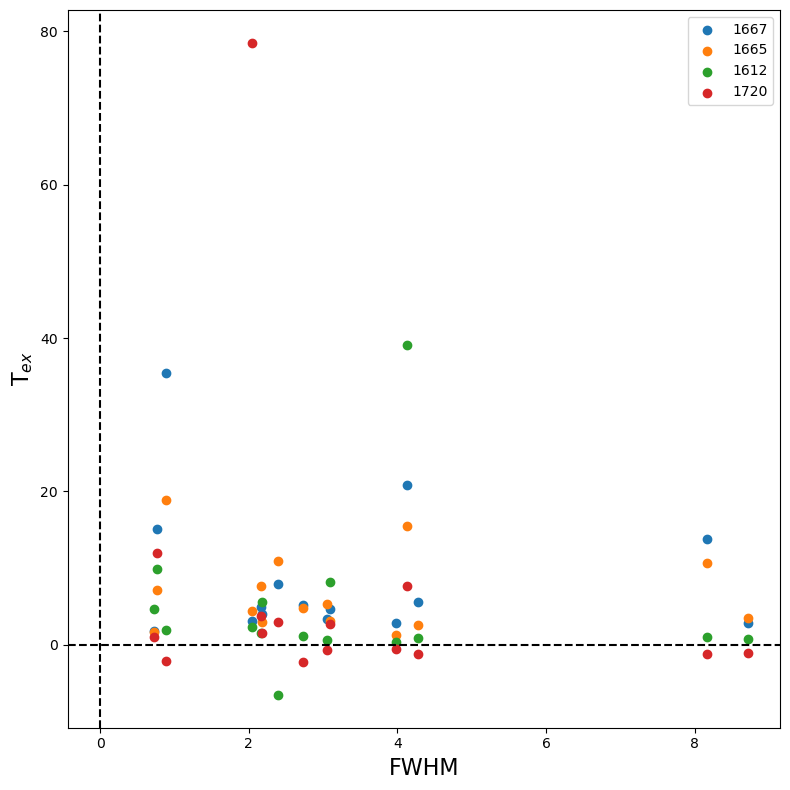

In [144]:
# Plot the data:
fig, axs = plt.subplots(1, figsize=(8, 8))

# Plot the OH:
axs.scatter(x=results[results.Line == 1667]['FWHM'], y=results[results.Line == 1667]['Tex'], marker='o', label='1667')
axs.scatter(x=results[results.Line == 1665]['FWHM'], y=results[results.Line == 1665]['Tex'], marker='o', label='1665')
axs.scatter(x=results[results.Line == 1612]['FWHM'], y=results[results.Line == 1612]['Tex'], marker='o', label='1612')
axs.scatter(x=results[results.Line == 1720]['FWHM'], y=results[results.Line == 1720]['Tex'], marker='o', label='1720')
#axs.errorbar(x=6, y=5.1, yerr=0.2, xerr=0.5, marker='*', color='red', markersize=14, label='Engelke (W5) 2018')
axs.set_ylabel(r'T$_{ex}$', size=16)
axs.set_xlabel(r'FWHM', size=16)
#axs.set_ylim([-10, 20])
#axs.set_xlim([-1, 0.5])
axs.axvline(0, color='k', ls='dashed')
axs.axhline(0, color='k', ls='dashed')
axs.legend()
#axs.set_title(r'Inverse $T_{\mathrm{ex}}$ of the 18cm OH Main Lines')

fig.tight_layout()
#fig.savefig("Diff_of_Ysat.pdf", format='pdf', dpi=400)
#fig.savefig("Diff_of_Ysat.png", format='png', dpi=400)